In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 13.4 MB/s eta 0:00:00


# 10x10(m) grid

In [ ]:
from imblearn.over_sampling import SMOTE from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold from sklearn.metrics import ( roc_auc_score, accuracy_score, precision_score, recall_score,  f1_score, confusion_matrix, roc_curve ) from sklearn.tree import DecisionTreeClassifier from sklearn.ensemble import RandomForestClassifier from xgboost import XGBClassifier from catboost import CatBoostClassifier import os, time import numpy as np import pandas as pd  def run_grid_and_evaluate_with_smote( X_tr, X_te, y_tr, y_te, features, output_dir,  sample_frac=0.1, cv=5, random_state=42 ):  os.makedirs(output_dir, exist_ok=True)   models = {  'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=random_state),  'RandomForest': RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=random_state),  'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=random_state),  'CatBoost': CatBoostClassifier(verbose=0, class_weights=[1, 13], random_state=random_state)  }   # Hyperparameter grids  param_grids = {  'DecisionTree': {  'max_depth': [10, 20], 'min_samples_split': [5, 10],  'min_samples_leaf': [2, 5], 'max_features': ['sqrt'],  'ccp_alpha': [0.0, 0.001]  },  'RandomForest': {  'n_estimators': [200, 600], 'max_depth': [20, 30],  'min_samples_split': [5, 10], 'max_features': ['sqrt']  },  'XGBoost': {  'n_estimators': [300, 700], 'max_depth': [6],  'learning_rate': [0.05, 0.1],  'scale_pos_weight': [len(y_tr[y_tr==0]) / len(y_tr[y_tr==1])]  },  'CatBoost': {  'iterations': [200,500], 'depth': [6],  'learning_rate': [0.03, 0.1]  }  }   if 0 < sample_frac < 1:  train_size = sample_frac  else:  train_size = int(sample_frac)   results = {}  for name, model in models.items():  print(f"\n▶ {name} Grid Search started (samples={train_size}, cv={cv})")   # 1. sampling & SMOTE  X_s, _, y_s, _ = train_test_split( X_tr, y_tr,  train_size=train_size,  stratify=y_tr,  random_state=random_state )  smote = SMOTE(random_state=random_state)  X_s_resampled, y_s_resampled = smote.fit_resample(X_s, y_s)   # 2. GridSearchCV  t0 = time.time()  gs = GridSearchCV( estimator=model,  param_grid=param_grids[name],  scoring='roc_auc',  cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state),  n_jobs=-1,  verbose=1 )  gs.fit(X_s_resampled, y_s_resampled)  t_search = time.time() - t0  print(f"⏱ search completed: {t_search:.1f}s, BestParams={gs.best_params_}")   # 3. retrain after SMOTE on entire training data  X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)  best = gs.best_estimator_  t1 = time.time()  best.fit(X_tr_resampled, y_tr_resampled)  t_fit = time.time() - t1  print(f"⏱ retraining completed (including SMOTE): {t_fit:.1f}s")   # 4. prediction and evaluation  y_proba = best.predict_proba(X_te)[:, 1]  y_pred = (y_proba > 0.5).astype(int)  cm = confusion_matrix(y_te, y_pred)  fpr, tpr, _ = roc_curve(y_te, y_proba)   results[name] = {  'best_model': best,  'time_search': t_search,  'time_fit': t_fit,  'AUC': roc_auc_score(y_te, y_proba),  'Accuracy': accuracy_score(y_te, y_pred),  'Precision': precision_score(y_te, y_pred),  'Recall': recall_score(y_te, y_pred),  'F1-Score': f1_score(y_te, y_pred),  'confusion_matrix': cm,  'fpr': fpr,  'tpr': tpr  }   # 5. Summary Save  summary = pd.DataFrame([  {  'Model': name,  'AUC': results[name]['AUC'],  'Accuracy': results[name]['Accuracy'],  'Precision': results[name]['Precision'],  'Recall': results[name]['Recall'],  'F1-Score': results[name]['F1-Score'],  'Time_Search': results[name]['time_search'],  'Time_Fit': results[name]['time_fit']  }  for name in results  ])  summary.to_csv(os.path.join(output_dir, 'model_comparison_summary.csv'), index=False)  print("\n✅ Summary saved to model_comparison_summary.csv")   return summary, results 

In [ ]:
# ─── Cell 2: load data·split·scaling and function call ───  import pandas as pd from sklearn.model_selection import train_test_split from sklearn.preprocessing import StandardScaler  # 1) CSV load df = pd.read_csv('/content/drive/MyDrive/URBAN+AI For Paper/파이선 코드/SCI/10grid/SCI_flood_risk_data.csv') features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ] target = 'dept_avg'  # 2) prepare X, y (binary classification) X = df[features].values y = (df[target] > 0).astype(int).values  # 3) 7:3 split & scaling X_tr, X_te, y_tr, y_te = train_test_split( X, y, train_size=0.7, stratify=y, random_state=42 ) sc = StandardScaler().fit(X_tr) X_tr = sc.transform(X_tr) X_te = sc.transform(X_te)

In [ ]:
 # 4) function call output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid' summary, results = run_grid_and_evaluate_with_smote( X_tr, X_te, y_tr, y_te, features, output_dir,  sample_frac=0.1, # 10% sampling of training data(≈1010,000 records)  cv=5,  random_state=42 )  print(summary) 

In [ ]:
import joblib  # ① saving for name, info in results.items():  path = os.path.join(output_dir, f"{name}_best_model2.pkl")  joblib.dump(info['best_model'], path)  print(f"Saved → {path}")  # ② loading (in next session) loaded_models = {  name: joblib.load(os.path.join(output_dir, f"{name}_best_model2.pkl"))  for name in results.keys() }

In [ ]:
# 5) 테스트셋·스케일러 Save (.npy,.pkl) np.save(os.path.join(output_dir, 'X_te2.npy'), X_te) np.save(os.path.join(output_dir, 'y_te2.npy'), y_te) joblib.dump(sc, os.path.join(output_dir, 'scaler2.pkl'))

In [ ]:
import os output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary' os.makedirs(output_dir, exist_ok=True)

In [ ]:
import joblib import numpy as np from sklearn.metrics import ( confusion_matrix, roc_curve, auc,  accuracy_score, precision_score, recall_score, f1_score )  # 1) load test data X_test = np.load(os.path.join(output_dir, '10grid/X_te2.npy')) y_test = np.load(os.path.join(output_dir, '10grid/y_te2.npy'))  # 2) load trained model models = {} for name in ['DecisionTree','RandomForest','XGBoost','CatBoost']:  model_path = os.path.join(output_dir, '10grid', f'{name}_best_model2.pkl')  models[name] = joblib.load(model_path)  # 3) results dictionary generation results = {} for name, model in models.items():  # prediction values  y_pred = model.predict(X_test)  y_proba = model.predict_proba(X_test)[:,1] # positive class probability   # confusion matrix  cm = confusion_matrix(y_test, y_pred)   # ROC & AUC  fpr, tpr, _ = roc_curve(y_test, y_proba)  roc_auc = auc(fpr, tpr)   # other metrics  acc = accuracy_score(y_test, y_pred)  prec = precision_score(y_test, y_pred)  rec = recall_score(y_test, y_pred)  f1 = f1_score(y_test, y_pred)   # save to dictionary  results[name] = {  'confusion_matrix': cm,  'fpr': fpr, 'tpr': tpr, 'AUC': roc_auc,  'Accuracy': acc, 'Precision': prec,  'Recall': rec, 'F1-Score': f1  } 

In [ ]:
# ─── Cell 1: define visualization functions ───  import matplotlib.pyplot as plt import seaborn as sns import numpy as np import pandas as pd from sklearn.metrics import confusion_matrix, roc_curve, auc import matplotlib.patches as patches from math import pi   def plot_confusion_matrices(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  visualize confusion matrices of 4 models in 2x2 subplots   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  # model name abbreviation mapping  name_mapping = {  'DecisionTree': 'DT',  'RandomForest': 'RF',  'XGBoost': 'XGBoost',  'CatBoost': 'CatBoost'  }   fig, axes = plt.subplots(2, 2, figsize=(12, 10))  axes = axes.ravel()   for idx, name in enumerate(model_names):  if name not in results:  continue   cm = results[name]['confusion_matrix']  ax = axes[idx]   # heatmap generation  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  square=True, cbar=False, ax=ax,  annot_kws={'size': 16, 'weight': 'bold'},  linewidths=2, linecolor='white')   # title and labels  ax.set_title(f'{name_mapping.get(name, name)}', fontsize=18, fontweight='bold', pad=10)  ax.set_xlabel('Predicted', fontsize=14)  ax.set_ylabel('Actual', fontsize=14)   # tick labels  ax.set_xticklabels(['Non-flood', 'Flood'], fontsize=12)  ax.set_yticklabels(['Non-flood', 'Flood'], fontsize=12, rotation=0)   # display accuracy (optional)  accuracy = results[name]['Accuracy']  ax.text(0.5, -0.15, f'Accuracy: {accuracy:.3f}',  transform=ax.transAxes, ha='center', fontsize=12)   plt.suptitle('Confusion Matrices Comparison', fontsize=20, fontweight='bold', y=0.98)  plt.tight_layout()  return fig  def plot_roc_curves(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  display ROC curves of all models in one plot   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  plt.figure(figsize=(10, 8))   # color settings  colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']  linestyles = ['-', '--', '-.', ':']   for idx, name in enumerate(model_names):  if name not in results:  continue   fpr = results[name]['fpr']  tpr = results[name]['tpr']  auc_score = results[name]['AUC']   plt.plot(fpr, tpr,  color=colors[idx],  linestyle=linestyles[idx],  linewidth=2.5,  label=f'{name} (AUC = {auc_score:.3f})')   # diagonal line (random classification baseline)  plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random Classifier')   # style settings  plt.xlabel('False Positive Rate (FPR)', fontsize=14)  plt.ylabel('True Positive Rate (TPR)', fontsize=14)  plt.title('ROC Curves Comparison', fontsize=18, fontweight='bold', pad=15)   # legend  plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)   # grid  plt.grid(True, alpha=0.3, linestyle='--')   # axis range  plt.xlim([-0.02, 1.02])  plt.ylim([-0.02, 1.02])   # background color  ax = plt.gca()  ax.set_facecolor('#f8f9fa')   plt.tight_layout()  return plt.gcf()  def plot_performance_pentagon(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  Performance Pentagon (Radar Chart) Visualization   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  # metrics settings  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # angle calculation  angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()  angles += angles[:1] # to close the circle   # color settings  colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']   fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))   for idx, name in enumerate(model_names):  if name not in results:  continue   # get each metric value  values = [results[name][metric] for metric in metrics]  values += values[:1] # to close the circle   # plot  ax.plot(angles, values, 'o-', linewidth=2.5,  color=colors[idx], label=name, markersize=8)  ax.fill(angles, values, alpha=0.15, color=colors[idx])   # axis settings  ax.set_xticks(angles[:-1])  ax.set_xticklabels(metrics, fontsize=14)  ax.set_ylim(0, 1)   # grid  ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])  ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)  ax.yaxis.grid(True, linestyle='--', alpha=0.7)  ax.xaxis.grid(True, linestyle='--', alpha=0.7)   # title and legend  plt.title('Performance Pentagon Comparison', fontsize=18, fontweight='bold', pad=30)  plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)   plt.tight_layout()  return fig  def plot_performance_heatmap(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  by model - performance metrics heatmap   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # prepare data  data = []  for name in model_names:  if name in results:  row = [results[name][metric] for metric in metrics]  data.append(row)   # DataFrame generation  df = pd.DataFrame(data, columns=metrics, index=[name for name in model_names if name in results])   # heatmap generation  plt.figure(figsize=(10, 6))  sns.heatmap(df, annot=True, fmt='.3f', cmap='YlOrRd',  cbar_kws={'label': 'Score'},  linewidths=1, linecolor='white',  annot_kws={'fontsize': 12})   plt.title('Model Performance Heatmap', fontsize=16, fontweight='bold', pad=15)  plt.xlabel('Metrics', fontsize=14)  plt.ylabel('Models', fontsize=14)  plt.xticks(rotation=0)  plt.yticks(rotation=0)   plt.tight_layout()  return plt.gcf()  def plot_metric_comparison_bars(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  bar chart for performance comparison of each model metric   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # prepare data  data = {metric: [] for metric in metrics}  models = []   for name in model_names:  if name in results:  models.append(name)  for metric in metrics:  data[metric].append(results[name][metric])   # subplot generation  fig, axes = plt.subplots(2, 3, figsize=(15, 10))  axes = axes.ravel()   colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']   for idx, metric in enumerate(metrics):  ax = axes[idx]  bars = ax.bar(models, data[metric], color=colors)   # value display  for bar in bars:  height = bar.get_height()  ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,  f'{height:.3f}', ha='center', va='bottom', fontsize=10)   ax.set_title(metric, fontsize=14, fontweight='bold')  ax.set_ylim(0, 1.1)  ax.set_ylabel('Score', fontsize=12)  ax.grid(axis='y', alpha=0.3)   # rotate x-axis labels  ax.set_xticklabels(models, rotation=45, ha='right')   # hide last subplot  axes[-1].set_visible(False)   plt.suptitle('Performance Metrics Comparison', fontsize=18, fontweight='bold')  plt.tight_layout()  return fig 

In [ ]:
 # ─── Cell 2: Visualization execution code ───  # 1. Confusion Matrices print("📊 Confusion Matrices generation in progress...") fig_cm = plot_confusion_matrices(results) plt.savefig(os.path.join(output_dir, 'confusion_matrices_comparison.png'), dpi=300, bbox_inches='tight') plt.show()  # 2. ROC Curves print("\n📈 ROC Curves generation in progress...") fig_roc = plot_roc_curves(results) plt.savefig(os.path.join(output_dir, 'roc_curves_comparison.png'), dpi=300, bbox_inches='tight') plt.show()  # 3. Performance Pentagon print("\n🎯 Performance Pentagon generation in progress...") fig_pentagon = plot_performance_pentagon(results) plt.savefig(os.path.join(output_dir, 'performance_pentagon.png'), dpi=300, bbox_inches='tight') plt.show()  # 4. Performance Heatmap print("\n🔥 Performance Heatmap generation in progress...") fig_heatmap = plot_performance_heatmap(results) plt.savefig(os.path.join(output_dir, 'performance_heatmap.png'), dpi=300, bbox_inches='tight') plt.show()  # 5. Metric Comparison Bars print("\n📊 Metric Comparison Bars generation in progress...") fig_bars = plot_metric_comparison_bars(results) plt.savefig(os.path.join(output_dir, 'metric_comparison_bars.png'), dpi=300, bbox_inches='tight') plt.show()  # 6. result summary table print("\n📋 performance summary:") summary_df = pd.DataFrame({  'Model': ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost'],  'AUC': [results[name]['AUC'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Accuracy': [results[name]['Accuracy'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Precision': [results[name]['Precision'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Recall': [results[name]['Recall'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'F1-Score': [results[name]['F1-Score'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']] })  # best performing model highlight print("\n🏆 best performance:") for metric in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']:  best_model = summary_df.loc[summary_df[metric].idxmax(), 'Model']  best_score = summary_df[metric].max()  print(f"{metric}: {best_model} ({best_score:.4f})")  print("\n✅ All visualizations completed!")

In [ ]:
pip install imbalanced-learn shap

In [ ]:
# ─── improved SHAP visualization code (ratio adjustment) ───  import numpy as np import pandas as pd import joblib import shap import matplotlib.pyplot as plt import os from matplotlib import gridspec  # 0) for visualization display name mapping display_name_map = {  'height': 'Altitude',  'slope_avg': 'Slope',  'river_distance_avg': 'Distance from River',  'drainscore_avg': 'Soil Drainage',  'permeable': 'Impermeable Area',  'distance_avg': 'Distance from Reservoir',  'length_sew': 'Length of Sewer Pipe',  'numpoints': 'Number of Manhole' }  # original features list features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ]  # Visualization to use display name list features_display = [display_name_map[f] for f in features]  # 1) settings output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝code/SCI/output/binary/10grid'  # 2) data and load model X_te = np.load(os.path.join(output_dir, 'X_te2.npy')) y_te = np.load(os.path.join(output_dir, 'y_te2.npy'))  # 3) sampling n_sample = 1500 np.random.seed(42) idx = np.random.choice(len(X_te), n_sample, replace=False) X_sample = X_te[idx]  # 4) all models for SHAP analysis models_to_analyze = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']  for model_name in models_to_analyze:  print(f"\n{'='*60}")  print(f"🔍 {model_name} analysis")  print('='*60)   # load model  model_path = os.path.join(output_dir, f"{model_name}_best_model2.pkl")  if not os.path.exists(model_path):  print(f"❌ {model_name} model file not found.")  continue   model = joblib.load(model_path)   # verify feature importance  print(f"\n📊 Feature Importance:")  feature_imp = pd.DataFrame({  'feature': features,  'importance': model.feature_importances_  }).sort_values('importance', ascending=False)  feature_imp['display_name'] = feature_imp['feature'].map(display_name_map)  print(feature_imp[feature_imp['importance'] > 0].head())  print(f"used feature count: {(model.feature_importances_ > 0).sum()}/{len(features)}")   # SHAP calculation  print(f"\n📊 SHAP calculation in progress...")  explainer = shap.TreeExplainer(model)  shap_values = explainer.shap_values(X_sample)   # check SHAP value shape and processing  if isinstance(shap_values, list):  shap_values = shap_values[1] # positive class   # 3D array processing (DT, RF case)  if len(shap_values.shape) == 3:  if shap_values.shape[2] == 2:  shap_values = shap_values[:,:, 1]  elif shap_values.shape[1] == shap_values.shape[2]:  shap_values = np.array([shap_values[i].diagonal() for i in range(shap_values.shape[0])])  else:  shap_values = shap_values.mean(axis=2)   # ========== improved Visualization ==========   # 방법 1: ratio adjustment using GridSpec  fig = plt.figure(figsize=(20, 8))  gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.3)   ax1 = plt.subplot(gs[0])  ax2 = plt.subplot(gs[1])   # 1. SHAP Summary Plot (left, wider)  plt.sca(ax1)  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  ax1.set_title(f'{model_name} - SHAP Summary Plot', fontsize=16, pad=15)  ax1.set_xlabel('SHAP value (impact on model output)', fontsize=12)   # 2. Feature Importance (right)  mean_abs_shap = np.abs(shap_values).mean(axis=0)   # sort in descending order  sorted_idx = np.argsort(mean_abs_shap)  sorted_features = [features_display[i] for i in sorted_idx]  sorted_values = mean_abs_shap[sorted_idx]   bars = ax2.barh(range(len(features)), sorted_values, color='#3498db')   # value display  for i, (feat, val) in enumerate(zip(sorted_features, sorted_values)):  if val > 0:  ax2.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)   ax2.set_yticks(range(len(features)))  ax2.set_yticklabels(sorted_features, fontsize=11)  ax2.set_xlabel('Mean |SHAP value|', fontsize=12)  ax2.set_title(f'{model_name} - Feature Importance', fontsize=16, pad=15)  ax2.grid(True, alpha=0.3, axis='x')   # adjust xaxis range (add margin)  max_val = sorted_values.max()  ax2.set_xlim(0, max_val * 1.15)   plt.tight_layout()  plt.savefig(os.path.join(output_dir, f'{model_name}_shap_analysis_wide.png'),  dpi=300, bbox_inches='tight')  plt.show()   # ========== alternative: vertical layout ==========   # version with vertical layout  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))   # 1. SHAP Summary Plot (top)  plt.sca(ax1)  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  ax1.set_title(f'{model_name} - SHAP Summary Plot', fontsize=16, pad=15)  ax1.set_xlabel('SHAP value (impact on model output)', fontsize=12)   # 2. Feature Importance (bottom)  # use vertical bars instead of horizontal bars  ax2.bar(range(len(features)), mean_abs_shap[sorted_idx][::-1], color='#e74c3c')  ax2.set_xticks(range(len(features)))  ax2.set_xticklabels([features_display[i] for i in sorted_idx[::-1]],  rotation=45, ha='right')  ax2.set_ylabel('Mean |SHAP value|', fontsize=12)  ax2.set_title(f'{model_name} - Feature Importance', fontsize=16, pad=15)  ax2.grid(True, alpha=0.3, axis='y')   # value display  for i, val in enumerate(mean_abs_shap[sorted_idx][::-1]):  if val > 0:  ax2.text(i, val + 0.002, f'{val:.3f}', ha='center', fontsize=10)   plt.tight_layout()  plt.savefig(os.path.join(output_dir, f'{model_name}_shap_analysis_vertical.png'),  dpi=300, bbox_inches='tight')  plt.show()   # ========== integrated visualization (4 models at once) ==========  # visualize all models SHAP results together print("\n\n📊 SHAP comparison visualization for all models")  fig, axes = plt.subplots(2, 2, figsize=(24, 16)) axes = axes.ravel()  for idx, model_name in enumerate(models_to_analyze):  model_path = os.path.join(output_dir, f"{model_name}_best_model2.pkl")  if not os.path.exists(model_path):  continue   model = joblib.load(model_path)  explainer = shap.TreeExplainer(model)  shap_values = explainer.shap_values(X_sample)   if isinstance(shap_values, list):  shap_values = shap_values[1]   if len(shap_values.shape) == 3:  if shap_values.shape[2] == 2:  shap_values = shap_values[:,:, 1]  elif shap_values.shape[1] == shap_values.shape[2]:  shap_values = np.array([shap_values[i].diagonal() for i in range(shap_values.shape[0])])   # SHAP summary plot for each subplot  plt.sca(axes[idx])  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  axes[idx].set_title(f'{model_name}', fontsize=18, fontweight='bold', pad=10)  axes[idx].set_xlabel('SHAP value (impact on model output)', fontsize=12)  plt.suptitle('SHAP Analysis Comparison - All Models', fontsize=22, fontweight='bold') plt.tight_layout() plt.savefig(os.path.join(output_dir, 'all_models_shap_comparison_grid.png'),  dpi=300, bbox_inches='tight') plt.show()  print("\n✅ improved SHAP visualization completed!")

# 30x30(m) grid

In [ ]:
from imblearn.over_sampling import SMOTE from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold from sklearn.metrics import ( roc_auc_score, accuracy_score, precision_score, recall_score,  f1_score, confusion_matrix, roc_curve ) from sklearn.tree import DecisionTreeClassifier from sklearn.ensemble import RandomForestClassifier from xgboost import XGBClassifier from catboost import CatBoostClassifier import os, time import numpy as np import pandas as pd  def run_grid_and_evaluate_with_smote( X_tr, X_te, y_tr, y_te, features, output_dir,  sample_frac=0.1, cv=5, random_state=42 ):  os.makedirs(output_dir, exist_ok=True)   models = {  'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=random_state),  'RandomForest': RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=random_state),  'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=random_state),  'CatBoost': CatBoostClassifier(verbose=0, class_weights=[1, 13], random_state=random_state)  }   # Hyperparameter grids  param_grids = {  'DecisionTree': {  'max_depth': [10, 20], 'min_samples_split': [5, 10],  'min_samples_leaf': [2, 5], 'max_features': ['sqrt'],  'ccp_alpha': [0.0, 0.001]  },  'RandomForest': {  'n_estimators': [200, 600], 'max_depth': [20, 30],  'min_samples_split': [5, 10], 'max_features': ['sqrt']  },  'XGBoost': {  'n_estimators': [300, 700], 'max_depth': [6],  'learning_rate': [0.05, 0.1],  'scale_pos_weight': [len(y_tr[y_tr==0]) / len(y_tr[y_tr==1])]  },  'CatBoost': {  'iterations': [200,500], 'depth': [6],  'learning_rate': [0.03, 0.1]  }  }   if 0 < sample_frac < 1:  train_size = sample_frac  else:  train_size = int(sample_frac)   results = {}  for name, model in models.items():  print(f"\n▶ {name} Grid Search started (samples={train_size}, cv={cv})")   # 1. sampling & SMOTE  X_s, _, y_s, _ = train_test_split( X_tr, y_tr,  train_size=train_size,  stratify=y_tr,  random_state=random_state )  smote = SMOTE(random_state=random_state)  X_s_resampled, y_s_resampled = smote.fit_resample(X_s, y_s)   # 2. GridSearchCV  t0 = time.time()  gs = GridSearchCV( estimator=model,  param_grid=param_grids[name],  scoring='roc_auc',  cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state),  n_jobs=-1,  verbose=1 )  gs.fit(X_s_resampled, y_s_resampled)  t_search = time.time() - t0  print(f"⏱ search completed: {t_search:.1f}s, BestParams={gs.best_params_}")   # 3. retrain after SMOTE on entire training data  X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)  best = gs.best_estimator_  t1 = time.time()  best.fit(X_tr_resampled, y_tr_resampled)  t_fit = time.time() - t1  print(f"⏱ retraining completed (including SMOTE): {t_fit:.1f}s")   # 4. prediction and evaluation  y_proba = best.predict_proba(X_te)[:, 1]  y_pred = (y_proba > 0.5).astype(int)  cm = confusion_matrix(y_te, y_pred)  fpr, tpr, _ = roc_curve(y_te, y_proba)   results[name] = {  'best_model': best,  'time_search': t_search,  'time_fit': t_fit,  'AUC': roc_auc_score(y_te, y_proba),  'Accuracy': accuracy_score(y_te, y_pred),  'Precision': precision_score(y_te, y_pred),  'Recall': recall_score(y_te, y_pred),  'F1-Score': f1_score(y_te, y_pred),  'confusion_matrix': cm,  'fpr': fpr,  'tpr': tpr  }   # 5. Summary Save  summary = pd.DataFrame([  {  'Model': name,  'AUC': results[name]['AUC'],  'Accuracy': results[name]['Accuracy'],  'Precision': results[name]['Precision'],  'Recall': results[name]['Recall'],  'F1-Score': results[name]['F1-Score'],  'Time_Search': results[name]['time_search'],  'Time_Fit': results[name]['time_fit']  }  for name in results  ])  summary.to_csv(os.path.join(output_dir, 'model_comparison_summary.csv'), index=False)  print("\n✅ Summary saved to model_comparison_summary.csv")   return summary, results 

In [ ]:
# ─── Cell 2: load data·split·scaling and function call ───  import pandas as pd from sklearn.model_selection import train_test_split from sklearn.preprocessing import StandardScaler  # 1) CSV load df = pd.read_csv('/content/drive/MyDrive/URBAN+AI For Paper/파이선 코드/SCI/30grid/SCI_30grid_flood_risk_data.csv') features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ] target = 'dept_avg'  # 2) prepare X, y (binary classification) X = df[features].values y = (df[target] > 0).astype(int).values  # 3) 7:3 split & scaling X_tr, X_te, y_tr, y_te = train_test_split( X, y, train_size=0.7, stratify=y, random_state=42 ) sc = StandardScaler().fit(X_tr) X_tr = sc.transform(X_tr) X_te = sc.transform(X_te)

In [ ]:
 # 4) function call output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/30grid' summary, results = run_grid_and_evaluate_with_smote( X_tr, X_te, y_tr, y_te, features, output_dir,  sample_frac=0.1, # 10% sampling of training data(≈1010,000 records)  cv=5,  random_state=42 )  print(summary) 

In [ ]:
import joblib  # ① saving for name, info in results.items():  path = os.path.join(output_dir, f"{name}_best_model2.pkl")  joblib.dump(info['best_model'], path)  print(f"Saved → {path}")  # ② loading (in next session) loaded_models = {  name: joblib.load(os.path.join(output_dir, f"{name}_best_model2.pkl"))  for name in results.keys() }

In [ ]:
# 5) 테스트셋·스케일러 Save (.npy,.pkl) np.save(os.path.join(output_dir, 'X_te2.npy'), X_te) np.save(os.path.join(output_dir, 'y_te2.npy'), y_te) joblib.dump(sc, os.path.join(output_dir, 'scaler2.pkl'))

In [ ]:
import os output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary' os.makedirs(output_dir, exist_ok=True)

In [ ]:
import joblib import numpy as np from sklearn.metrics import ( confusion_matrix, roc_curve, auc,  accuracy_score, precision_score, recall_score, f1_score )  # 1) load test data X_test = np.load(os.path.join(output_dir, '30grid/X_te2.npy')) y_test = np.load(os.path.join(output_dir, '30grid/y_te2.npy'))  # 2) load trained model models = {} for name in ['DecisionTree','RandomForest','XGBoost','CatBoost']:  model_path = os.path.join(output_dir, '30grid', f'{name}_best_model2.pkl')  models[name] = joblib.load(model_path)  # 3) results dictionary generation results = {} for name, model in models.items():  # prediction values  y_pred = model.predict(X_test)  y_proba = model.predict_proba(X_test)[:,1] # positive class probability   # confusion matrix  cm = confusion_matrix(y_test, y_pred)   # ROC & AUC  fpr, tpr, _ = roc_curve(y_test, y_proba)  roc_auc = auc(fpr, tpr)   # other metrics  acc = accuracy_score(y_test, y_pred)  prec = precision_score(y_test, y_pred)  rec = recall_score(y_test, y_pred)  f1 = f1_score(y_test, y_pred)   # save to dictionary  results[name] = {  'confusion_matrix': cm,  'fpr': fpr, 'tpr': tpr, 'AUC': roc_auc,  'Accuracy': acc, 'Precision': prec,  'Recall': rec, 'F1-Score': f1  } 

In [ ]:
# ─── Cell 1: define visualization functions ───  import matplotlib.pyplot as plt import seaborn as sns import numpy as np import pandas as pd from sklearn.metrics import confusion_matrix, roc_curve, auc import matplotlib.patches as patches from math import pi   def plot_confusion_matrices(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  visualize confusion matrices of 4 models in 2x2 subplots   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  # model name abbreviation mapping  name_mapping = {  'DecisionTree': 'DT',  'RandomForest': 'RF',  'XGBoost': 'XGBoost',  'CatBoost': 'CatBoost'  }   fig, axes = plt.subplots(2, 2, figsize=(12, 10))  axes = axes.ravel()   for idx, name in enumerate(model_names):  if name not in results:  continue   cm = results[name]['confusion_matrix']  ax = axes[idx]   # heatmap generation  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  square=True, cbar=False, ax=ax,  annot_kws={'size': 16, 'weight': 'bold'},  linewidths=2, linecolor='white')   # title and labels  ax.set_title(f'{name_mapping.get(name, name)}', fontsize=18, fontweight='bold', pad=10)  ax.set_xlabel('Predicted', fontsize=14)  ax.set_ylabel('Actual', fontsize=14)   # tick labels  ax.set_xticklabels(['Non-flood', 'Flood'], fontsize=12)  ax.set_yticklabels(['Non-flood', 'Flood'], fontsize=12, rotation=0)   # display accuracy (optional)  accuracy = results[name]['Accuracy']  ax.text(0.5, -0.15, f'Accuracy: {accuracy:.3f}',  transform=ax.transAxes, ha='center', fontsize=12)   plt.suptitle('Confusion Matrices Comparison', fontsize=20, fontweight='bold', y=0.98)  plt.tight_layout()  return fig  def plot_roc_curves(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  display ROC curves of all models in one plot   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  plt.figure(figsize=(10, 8))   # color settings  colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']  linestyles = ['-', '--', '-.', ':']   for idx, name in enumerate(model_names):  if name not in results:  continue   fpr = results[name]['fpr']  tpr = results[name]['tpr']  auc_score = results[name]['AUC']   plt.plot(fpr, tpr,  color=colors[idx],  linestyle=linestyles[idx],  linewidth=2.5,  label=f'{name} (AUC = {auc_score:.3f})')   # diagonal line (random classification baseline)  plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random Classifier')   # style settings  plt.xlabel('False Positive Rate (FPR)', fontsize=14)  plt.ylabel('True Positive Rate (TPR)', fontsize=14)  plt.title('ROC Curves Comparison', fontsize=18, fontweight='bold', pad=15)   # legend  plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)   # grid  plt.grid(True, alpha=0.3, linestyle='--')   # axis range  plt.xlim([-0.02, 1.02])  plt.ylim([-0.02, 1.02])   # background color  ax = plt.gca()  ax.set_facecolor('#f8f9fa')   plt.tight_layout()  return plt.gcf()  def plot_performance_pentagon(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  Performance Pentagon (Radar Chart) Visualization   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  # metrics settings  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # angle calculation  angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()  angles += angles[:1] # to close the circle   # color settings  colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']   fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))   for idx, name in enumerate(model_names):  if name not in results:  continue   # get each metric value  values = [results[name][metric] for metric in metrics]  values += values[:1] # to close the circle   # plot  ax.plot(angles, values, 'o-', linewidth=2.5,  color=colors[idx], label=name, markersize=8)  ax.fill(angles, values, alpha=0.15, color=colors[idx])   # axis settings  ax.set_xticks(angles[:-1])  ax.set_xticklabels(metrics, fontsize=14)  ax.set_ylim(0, 1)   # grid  ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])  ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)  ax.yaxis.grid(True, linestyle='--', alpha=0.7)  ax.xaxis.grid(True, linestyle='--', alpha=0.7)   # title and legend  plt.title('Performance Pentagon Comparison', fontsize=18, fontweight='bold', pad=30)  plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)   plt.tight_layout()  return fig  def plot_performance_heatmap(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  by model - performance metrics heatmap   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # prepare data  data = []  for name in model_names:  if name in results:  row = [results[name][metric] for metric in metrics]  data.append(row)   # DataFrame generation  df = pd.DataFrame(data, columns=metrics, index=[name for name in model_names if name in results])   # heatmap generation  plt.figure(figsize=(10, 6))  sns.heatmap(df, annot=True, fmt='.3f', cmap='YlOrRd',  cbar_kws={'label': 'Score'},  linewidths=1, linecolor='white',  annot_kws={'fontsize': 12})   plt.title('Model Performance Heatmap', fontsize=16, fontweight='bold', pad=15)  plt.xlabel('Metrics', fontsize=14)  plt.ylabel('Models', fontsize=14)  plt.xticks(rotation=0)  plt.yticks(rotation=0)   plt.tight_layout()  return plt.gcf()  def plot_metric_comparison_bars(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  bar chart for performance comparison of each model metric   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # prepare data  data = {metric: [] for metric in metrics}  models = []   for name in model_names:  if name in results:  models.append(name)  for metric in metrics:  data[metric].append(results[name][metric])   # subplot generation  fig, axes = plt.subplots(2, 3, figsize=(15, 10))  axes = axes.ravel()   colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']   for idx, metric in enumerate(metrics):  ax = axes[idx]  bars = ax.bar(models, data[metric], color=colors)   # value display  for bar in bars:  height = bar.get_height()  ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,  f'{height:.3f}', ha='center', va='bottom', fontsize=10)   ax.set_title(metric, fontsize=14, fontweight='bold')  ax.set_ylim(0, 1.1)  ax.set_ylabel('Score', fontsize=12)  ax.grid(axis='y', alpha=0.3)   # rotate x-axis labels  ax.set_xticklabels(models, rotation=45, ha='right')   # hide last subplot  axes[-1].set_visible(False)   plt.suptitle('Performance Metrics Comparison', fontsize=18, fontweight='bold')  plt.tight_layout()  return fig 

In [ ]:
 # ─── Cell 2: Visualization execution code ───  # 1. Confusion Matrices print("📊 Confusion Matrices generation in progress...") fig_cm = plot_confusion_matrices(results) plt.savefig(os.path.join(output_dir, 'confusion_matrices_comparison.png'), dpi=300, bbox_inches='tight') plt.show()  # 2. ROC Curves print("\n📈 ROC Curves generation in progress...") fig_roc = plot_roc_curves(results) plt.savefig(os.path.join(output_dir, 'roc_curves_comparison.png'), dpi=300, bbox_inches='tight') plt.show()  # 3. Performance Pentagon print("\n🎯 Performance Pentagon generation in progress...") fig_pentagon = plot_performance_pentagon(results) plt.savefig(os.path.join(output_dir, 'performance_pentagon.png'), dpi=300, bbox_inches='tight') plt.show()  # 4. Performance Heatmap print("\n🔥 Performance Heatmap generation in progress...") fig_heatmap = plot_performance_heatmap(results) plt.savefig(os.path.join(output_dir, 'performance_heatmap.png'), dpi=300, bbox_inches='tight') plt.show()  # 5. Metric Comparison Bars print("\n📊 Metric Comparison Bars generation in progress...") fig_bars = plot_metric_comparison_bars(results) plt.savefig(os.path.join(output_dir, 'metric_comparison_bars.png'), dpi=300, bbox_inches='tight') plt.show()  # 6. result summary table print("\n📋 performance summary:") summary_df = pd.DataFrame({  'Model': ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost'],  'AUC': [results[name]['AUC'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Accuracy': [results[name]['Accuracy'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Precision': [results[name]['Precision'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Recall': [results[name]['Recall'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'F1-Score': [results[name]['F1-Score'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']] })  # best performing model highlight print("\n🏆 best performance:") for metric in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']:  best_model = summary_df.loc[summary_df[metric].idxmax(), 'Model']  best_score = summary_df[metric].max()  print(f"{metric}: {best_model} ({best_score:.4f})")  print("\n✅ All visualizations completed!")

In [ ]:
# ─── improved SHAP visualization code (ratio adjustment) ───  import numpy as np import pandas as pd import joblib import shap import matplotlib.pyplot as plt import os from matplotlib import gridspec  # 0) for visualization display name mapping display_name_map = {  'height': 'Altitude',  'slope_avg': 'Slope',  'river_distance_avg': 'Distance from River',  'drainscore_avg': 'Soil Drainage',  'permeable': 'Impermeable Area',  'distance_avg': 'Distance from Reservoir',  'length_sew': 'Length of Sewer Pipe',  'numpoints': 'Number of Manhole' }  # original features list features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ]  # Visualization to use display name list features_display = [display_name_map[f] for f in features]  # 1) settings output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝code/SCI/output/binary/30grid'  # 2) data and load model X_te = np.load(os.path.join(output_dir, 'X_te2.npy')) y_te = np.load(os.path.join(output_dir, 'y_te2.npy'))  # 3) sampling n_sample = 1500 np.random.seed(42) idx = np.random.choice(len(X_te), n_sample, replace=False) X_sample = X_te[idx]  # 4) all models for SHAP analysis models_to_analyze = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']  for model_name in models_to_analyze:  print(f"\n{'='*60}")  print(f"🔍 {model_name} analysis")  print('='*60)   # load model  model_path = os.path.join(output_dir, f"{model_name}_best_model2.pkl")  if not os.path.exists(model_path):  print(f"❌ {model_name} model file not found.")  continue   model = joblib.load(model_path)   # verify feature importance  print(f"\n📊 Feature Importance:")  feature_imp = pd.DataFrame({  'feature': features,  'importance': model.feature_importances_  }).sort_values('importance', ascending=False)  feature_imp['display_name'] = feature_imp['feature'].map(display_name_map)  print(feature_imp[feature_imp['importance'] > 0].head())  print(f"used feature count: {(model.feature_importances_ > 0).sum()}/{len(features)}")   # SHAP calculation  print(f"\n📊 SHAP calculation in progress...")  explainer = shap.TreeExplainer(model)  shap_values = explainer.shap_values(X_sample)   # check SHAP value shape and processing  if isinstance(shap_values, list):  shap_values = shap_values[1] # positive class   # 3D array processing (DT, RF case)  if len(shap_values.shape) == 3:  if shap_values.shape[2] == 2:  shap_values = shap_values[:,:, 1]  elif shap_values.shape[1] == shap_values.shape[2]:  shap_values = np.array([shap_values[i].diagonal() for i in range(shap_values.shape[0])])  else:  shap_values = shap_values.mean(axis=2)   # ========== improved Visualization ==========   # 방법 1: ratio adjustment using GridSpec  fig = plt.figure(figsize=(20, 8))  gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.3)   ax1 = plt.subplot(gs[0])  ax2 = plt.subplot(gs[1])   # 1. SHAP Summary Plot (left, wider)  plt.sca(ax1)  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  ax1.set_title(f'{model_name} - SHAP Summary Plot', fontsize=16, pad=15)  ax1.set_xlabel('SHAP value (impact on model output)', fontsize=12)   # 2. Feature Importance (right)  mean_abs_shap = np.abs(shap_values).mean(axis=0)   # sort in descending order  sorted_idx = np.argsort(mean_abs_shap)  sorted_features = [features_display[i] for i in sorted_idx]  sorted_values = mean_abs_shap[sorted_idx]   bars = ax2.barh(range(len(features)), sorted_values, color='#3498db')   # value display  for i, (feat, val) in enumerate(zip(sorted_features, sorted_values)):  if val > 0:  ax2.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)   ax2.set_yticks(range(len(features)))  ax2.set_yticklabels(sorted_features, fontsize=11)  ax2.set_xlabel('Mean |SHAP value|', fontsize=12)  ax2.set_title(f'{model_name} - Feature Importance', fontsize=16, pad=15)  ax2.grid(True, alpha=0.3, axis='x')   # adjust xaxis range (add margin)  max_val = sorted_values.max()  ax2.set_xlim(0, max_val * 1.15)   plt.tight_layout()  plt.savefig(os.path.join(output_dir, f'{model_name}_shap_analysis_wide.png'),  dpi=300, bbox_inches='tight')  plt.show()   # ========== alternative: vertical layout ==========   # version with vertical layout  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))   # 1. SHAP Summary Plot (top)  plt.sca(ax1)  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  ax1.set_title(f'{model_name} - SHAP Summary Plot', fontsize=16, pad=15)  ax1.set_xlabel('SHAP value (impact on model output)', fontsize=12)   # 2. Feature Importance (bottom)  # use vertical bars instead of horizontal bars  ax2.bar(range(len(features)), mean_abs_shap[sorted_idx][::-1], color='#e74c3c')  ax2.set_xticks(range(len(features)))  ax2.set_xticklabels([features_display[i] for i in sorted_idx[::-1]],  rotation=45, ha='right')  ax2.set_ylabel('Mean |SHAP value|', fontsize=12)  ax2.set_title(f'{model_name} - Feature Importance', fontsize=16, pad=15)  ax2.grid(True, alpha=0.3, axis='y')   # value display  for i, val in enumerate(mean_abs_shap[sorted_idx][::-1]):  if val > 0:  ax2.text(i, val + 0.002, f'{val:.3f}', ha='center', fontsize=10)   plt.tight_layout()  plt.savefig(os.path.join(output_dir, f'{model_name}_shap_analysis_vertical.png'),  dpi=300, bbox_inches='tight')  plt.show()   # ========== integrated visualization (4 models at once) ==========  # visualize all models SHAP results together print("\n\n📊 SHAP comparison visualization for all models")  fig, axes = plt.subplots(2, 2, figsize=(24, 16)) axes = axes.ravel()  for idx, model_name in enumerate(models_to_analyze):  model_path = os.path.join(output_dir, f"{model_name}_best_model2.pkl")  if not os.path.exists(model_path):  continue   model = joblib.load(model_path)  explainer = shap.TreeExplainer(model)  shap_values = explainer.shap_values(X_sample)   if isinstance(shap_values, list):  shap_values = shap_values[1]   if len(shap_values.shape) == 3:  if shap_values.shape[2] == 2:  shap_values = shap_values[:,:, 1]  elif shap_values.shape[1] == shap_values.shape[2]:  shap_values = np.array([shap_values[i].diagonal() for i in range(shap_values.shape[0])])   # SHAP summary plot for each subplot  plt.sca(axes[idx])  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  axes[idx].set_title(f'{model_name}', fontsize=18, fontweight='bold', pad=10)  axes[idx].set_xlabel('SHAP value (impact on model output)', fontsize=12)  plt.suptitle('SHAP Analysis Comparison - All Models', fontsize=22, fontweight='bold') plt.tight_layout() plt.savefig(os.path.join(output_dir, 'all_models_shap_comparison_grid.png'),  dpi=300, bbox_inches='tight') plt.show()  print("\n✅ improved SHAP visualization completed!")

In [ ]:
# ─── SHAP and Feature Importance 정량적 statistics (Visualization 후 실행) ───  import numpy as np import pandas as pd import joblib import shap import os  # 0) settings output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝code/SCI/output/binary/30grid' n_sample = 1500 # same as previously used sample count  # display name mapping display_name_map = {  'height': 'Altitude',  'slope_avg': 'Slope',  'river_distance_avg': 'Distance from River',  'drainscore_avg': 'Soil Drainage',  'permeable': 'Impermeable Area',  'distance_avg': 'Distance from Reservoir',  'length_sew': 'Length of Sewer Pipe',  'numpoints': 'Number of Manhole' }  features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ]  # Load data (미 load되어 있다면 records너뛰기) X_te = np.load(os.path.join(output_dir, 'X_te2.npy')) np.random.seed(42) idx = np.random.choice(len(X_te), n_sample, replace=False) X_sample = X_te[idx]  # all models statistics Save할 dictionary all_stats = {} models = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']  print("="*100) print("📊 Feature Importance and SHAP value 정량적 statistics") print("="*100)  # each by model - statistics calculation for model_name in models:  print(f"\n{'='*80}")  print(f"📌 {model_name}")  print('='*80)   # load model  model = joblib.load(os.path.join(output_dir, f"{model_name}_best_model2.pkl"))   # SHAP calculation  explainer = shap.TreeExplainer(model)  shap_values = explainer.shap_values(X_sample)   # processing  if isinstance(shap_values, list):  shap_values = shap_values[1]  if len(shap_values.shape) == 3:  if shap_values.shape[2] == 2:  shap_values = shap_values[:,:, 1]  elif shap_values.shape[1] == shap_values.shape[2]:  shap_values = np.array([shap_values[i].diagonal() for i in range(shap_values.shape[0])])   # statistics calculation  stats_list = []  for i, feat in enumerate(features):  stats = {  'Feature': display_name_map[feat],  'Model_Importance': model.feature_importances_[i],  'SHAP_Mean_Abs': np.abs(shap_values[:, i]).mean(),  'SHAP_Std': shap_values[:, i].std(),  'SHAP_Min': shap_values[:, i].min(),  'SHAP_Max': shap_values[:, i].max()  }  stats_list.append(stats)   # DataFrame generation and sort  df = pd.DataFrame(stats_list).sort_values('SHAP_Mean_Abs', ascending=False)  all_stats[model_name] = df   # 출력  print(df.to_string(index=False, float_format='%.6f'))   # Top 3  print(f"\n🏆 Top 3 Features:")  for i, row in df.head(3).iterrows():  print(f" {i+1}. {row['Feature']}: SHAP={row['SHAP_Mean_Abs']:.4f}, Importance={row['Model_Importance']:.4f}")  # all comparison table print("\n\n" + "="*100) print("📊 all models SHAP Mean |Absolute| comparison") print("="*100)  # 피벗 table generation comparison = pd.DataFrame({'Feature': [display_name_map[f] for f in features]}) for model_name in models:  comparison[model_name] = all_stats[model_name].set_index('Feature')['SHAP_Mean_Abs'].reindex(comparison['Feature']).values  comparison['Average'] = comparison[models].mean(axis=1) comparison = comparison.sort_values('Average', ascending=False)  print(comparison.to_string(index=False, float_format='%.6f'))  # Excel로 Save with pd.ExcelWriter(os.path.join(output_dir, 'feature_statistics.xlsx')) as writer:  for model_name, df in all_stats.items():  df.to_excel(writer, sheet_name=model_name, index=False)  comparison.to_excel(writer, sheet_name='Comparison', index=False)  print(f"\n💾 result가 feature_statistics.xlsx file로 Save되었습니다.") print("\n✅ analysis completed!")

# 100x100(m) grid

In [ ]:
from imblearn.over_sampling import SMOTE from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold from sklearn.metrics import ( roc_auc_score, accuracy_score, precision_score, recall_score,  f1_score, confusion_matrix, roc_curve ) from sklearn.tree import DecisionTreeClassifier from sklearn.ensemble import RandomForestClassifier from xgboost import XGBClassifier from catboost import CatBoostClassifier import os, time import numpy as np import pandas as pd  def run_grid_and_evaluate_with_smote( X_tr, X_te, y_tr, y_te, features, output_dir,  sample_frac=0.5, cv=5, random_state=42 ):  os.makedirs(output_dir, exist_ok=True)   models = {  'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=random_state),  'RandomForest': RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=random_state),  'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=random_state),  'CatBoost': CatBoostClassifier(verbose=0, class_weights=[1, 13], random_state=random_state)  }   # Hyperparameter grids  param_grids = {  'DecisionTree': {  'max_depth': [10, 20], 'min_samples_split': [5, 10],  'min_samples_leaf': [2, 5], 'max_features': ['sqrt'],  'ccp_alpha': [0.0, 0.001]  },  'RandomForest': {  'n_estimators': [200, 600], 'max_depth': [20, 30],  'min_samples_split': [5, 10], 'max_features': ['sqrt']  },  'XGBoost': {  'n_estimators': [300, 700], 'max_depth': [6],  'learning_rate': [0.05, 0.1],  'scale_pos_weight': [len(y_tr[y_tr==0]) / len(y_tr[y_tr==1])]  },  'CatBoost': {  'iterations': [200,500], 'depth': [6],  'learning_rate': [0.03, 0.1]  }  }   if 0 < sample_frac < 1:  train_size = sample_frac  else:  train_size = int(sample_frac)   results = {}  for name, model in models.items():  print(f"\n▶ {name} Grid Search started (samples={train_size}, cv={cv})")   # 1. sampling & SMOTE  X_s, _, y_s, _ = train_test_split( X_tr, y_tr,  train_size=train_size,  stratify=y_tr,  random_state=random_state )  smote = SMOTE(random_state=random_state)  X_s_resampled, y_s_resampled = smote.fit_resample(X_s, y_s)   # 2. GridSearchCV  t0 = time.time()  gs = GridSearchCV( estimator=model,  param_grid=param_grids[name],  scoring='roc_auc',  cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state),  n_jobs=-1,  verbose=1 )  gs.fit(X_s_resampled, y_s_resampled)  t_search = time.time() - t0  print(f"⏱ search completed: {t_search:.1f}s, BestParams={gs.best_params_}")   # 3. retrain after SMOTE on entire training data  X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)  best = gs.best_estimator_  t1 = time.time()  best.fit(X_tr_resampled, y_tr_resampled)  t_fit = time.time() - t1  print(f"⏱ retraining completed (including SMOTE): {t_fit:.1f}s")   # 4. prediction and evaluation  y_proba = best.predict_proba(X_te)[:, 1]  y_pred = (y_proba > 0.5).astype(int)  cm = confusion_matrix(y_te, y_pred)  fpr, tpr, _ = roc_curve(y_te, y_proba)   results[name] = {  'best_model': best,  'time_search': t_search,  'time_fit': t_fit,  'AUC': roc_auc_score(y_te, y_proba),  'Accuracy': accuracy_score(y_te, y_pred),  'Precision': precision_score(y_te, y_pred),  'Recall': recall_score(y_te, y_pred),  'F1-Score': f1_score(y_te, y_pred),  'confusion_matrix': cm,  'fpr': fpr,  'tpr': tpr  }   # 5. Summary Save  summary = pd.DataFrame([  {  'Model': name,  'AUC': results[name]['AUC'],  'Accuracy': results[name]['Accuracy'],  'Precision': results[name]['Precision'],  'Recall': results[name]['Recall'],  'F1-Score': results[name]['F1-Score'],  'Time_Search': results[name]['time_search'],  'Time_Fit': results[name]['time_fit']  }  for name in results  ])  summary.to_csv(os.path.join(output_dir, 'model_comparison_summary.csv'), index=False)  print("\n✅ Summary saved to model_comparison_summary.csv")   return summary, results 

In [ ]:
# ─── Cell 2: load data·split·scaling and function call ───  import pandas as pd from sklearn.model_selection import train_test_split from sklearn.preprocessing import StandardScaler  # 1) CSV load df = pd.read_csv('/content/drive/MyDrive/URBAN+AI For Paper/파이선 코드/SCI/100grid/SCI_100grid_flood_risk_data.csv') features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ] target = 'dept_avg'  # 2) prepare X, y (binary classification) X = df[features].values y = (df[target] > 0).astype(int).values  # 3) 7:3 split & scaling X_tr, X_te, y_tr, y_te = train_test_split( X, y, train_size=0.7, stratify=y, random_state=42 ) sc = StandardScaler().fit(X_tr) X_tr = sc.transform(X_tr) X_te = sc.transform(X_te)

In [ ]:
 # 4) function call output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/100grid' summary, results = run_grid_and_evaluate_with_smote( X_tr, X_te, y_tr, y_te, features, output_dir,  sample_frac=0.5, # 10% sampling of training data(≈1010,000 records)  cv=5,  random_state=42 )  print(summary) 

In [ ]:
import joblib  # ① saving for name, info in results.items():  path = os.path.join(output_dir, f"{name}_best_model2.pkl")  joblib.dump(info['best_model'], path)  print(f"Saved → {path}")  # ② loading (in next session) loaded_models = {  name: joblib.load(os.path.join(output_dir, f"{name}_best_model2.pkl"))  for name in results.keys() }

In [ ]:
# 5) 테스트셋·스케일러 Save (.npy,.pkl) np.save(os.path.join(output_dir, 'X_te2.npy'), X_te) np.save(os.path.join(output_dir, 'y_te2.npy'), y_te) joblib.dump(sc, os.path.join(output_dir, 'scaler2.pkl'))

In [ ]:
import os output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary' os.makedirs(output_dir, exist_ok=True)

In [ ]:
import joblib import numpy as np from sklearn.metrics import ( confusion_matrix, roc_curve, auc,  accuracy_score, precision_score, recall_score, f1_score )  # 1) load test data X_test = np.load(os.path.join(output_dir, '100grid/X_te2.npy')) y_test = np.load(os.path.join(output_dir, '100grid/y_te2.npy'))  # 2) load trained model models = {} for name in ['DecisionTree','RandomForest','XGBoost','CatBoost']:  model_path = os.path.join(output_dir, '100grid', f'{name}_best_model2.pkl')  models[name] = joblib.load(model_path)  # 3) results dictionary generation results = {} for name, model in models.items():  # prediction values  y_pred = model.predict(X_test)  y_proba = model.predict_proba(X_test)[:,1] # positive class probability   # confusion matrix  cm = confusion_matrix(y_test, y_pred)   # ROC & AUC  fpr, tpr, _ = roc_curve(y_test, y_proba)  roc_auc = auc(fpr, tpr)   # other metrics  acc = accuracy_score(y_test, y_pred)  prec = precision_score(y_test, y_pred)  rec = recall_score(y_test, y_pred)  f1 = f1_score(y_test, y_pred)   # save to dictionary  results[name] = {  'confusion_matrix': cm,  'fpr': fpr, 'tpr': tpr, 'AUC': roc_auc,  'Accuracy': acc, 'Precision': prec,  'Recall': rec, 'F1-Score': f1  } 

In [ ]:
# ─── Cell 1: define visualization functions ───  import matplotlib.pyplot as plt import seaborn as sns import numpy as np import pandas as pd from sklearn.metrics import confusion_matrix, roc_curve, auc import matplotlib.patches as patches from math import pi   def plot_confusion_matrices(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  visualize confusion matrices of 4 models in 2x2 subplots   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  # model name abbreviation mapping  name_mapping = {  'DecisionTree': 'DT',  'RandomForest': 'RF',  'XGBoost': 'XGBoost',  'CatBoost': 'CatBoost'  }   fig, axes = plt.subplots(2, 2, figsize=(12, 10))  axes = axes.ravel()   for idx, name in enumerate(model_names):  if name not in results:  continue   cm = results[name]['confusion_matrix']  ax = axes[idx]   # heatmap generation  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  square=True, cbar=False, ax=ax,  annot_kws={'size': 16, 'weight': 'bold'},  linewidths=2, linecolor='white')   # title and labels  ax.set_title(f'{name_mapping.get(name, name)}', fontsize=18, fontweight='bold', pad=10)  ax.set_xlabel('Predicted', fontsize=14)  ax.set_ylabel('Actual', fontsize=14)   # tick labels  ax.set_xticklabels(['Non-flood', 'Flood'], fontsize=12)  ax.set_yticklabels(['Non-flood', 'Flood'], fontsize=12, rotation=0)   # display accuracy (optional)  accuracy = results[name]['Accuracy']  ax.text(0.5, -0.15, f'Accuracy: {accuracy:.3f}',  transform=ax.transAxes, ha='center', fontsize=12)   plt.suptitle('Confusion Matrices Comparison', fontsize=20, fontweight='bold', y=0.98)  plt.tight_layout()  return fig  def plot_roc_curves(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  display ROC curves of all models in one plot   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  plt.figure(figsize=(10, 8))   # color settings  colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']  linestyles = ['-', '--', '-.', ':']   for idx, name in enumerate(model_names):  if name not in results:  continue   fpr = results[name]['fpr']  tpr = results[name]['tpr']  auc_score = results[name]['AUC']   plt.plot(fpr, tpr,  color=colors[idx],  linestyle=linestyles[idx],  linewidth=2.5,  label=f'{name} (AUC = {auc_score:.3f})')   # diagonal line (random classification baseline)  plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random Classifier')   # style settings  plt.xlabel('False Positive Rate (FPR)', fontsize=14)  plt.ylabel('True Positive Rate (TPR)', fontsize=14)  plt.title('ROC Curves Comparison', fontsize=18, fontweight='bold', pad=15)   # legend  plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)   # grid  plt.grid(True, alpha=0.3, linestyle='--')   # axis range  plt.xlim([-0.02, 1.02])  plt.ylim([-0.02, 1.02])   # background color  ax = plt.gca()  ax.set_facecolor('#f8f9fa')   plt.tight_layout()  return plt.gcf()  def plot_performance_pentagon(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  Performance Pentagon (Radar Chart) Visualization   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  # metrics settings  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # angle calculation  angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()  angles += angles[:1] # to close the circle   # color settings  colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']   fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))   for idx, name in enumerate(model_names):  if name not in results:  continue   # get each metric value  values = [results[name][metric] for metric in metrics]  values += values[:1] # to close the circle   # plot  ax.plot(angles, values, 'o-', linewidth=2.5,  color=colors[idx], label=name, markersize=8)  ax.fill(angles, values, alpha=0.15, color=colors[idx])   # axis settings  ax.set_xticks(angles[:-1])  ax.set_xticklabels(metrics, fontsize=14)  ax.set_ylim(0, 1)   # grid  ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])  ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)  ax.yaxis.grid(True, linestyle='--', alpha=0.7)  ax.xaxis.grid(True, linestyle='--', alpha=0.7)   # title and legend  plt.title('Performance Pentagon Comparison', fontsize=18, fontweight='bold', pad=30)  plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)   plt.tight_layout()  return fig  def plot_performance_heatmap(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  by model - performance metrics heatmap   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # prepare data  data = []  for name in model_names:  if name in results:  row = [results[name][metric] for metric in metrics]  data.append(row)   # DataFrame generation  df = pd.DataFrame(data, columns=metrics, index=[name for name in model_names if name in results])   # heatmap generation  plt.figure(figsize=(10, 6))  sns.heatmap(df, annot=True, fmt='.3f', cmap='YlOrRd',  cbar_kws={'label': 'Score'},  linewidths=1, linecolor='white',  annot_kws={'fontsize': 12})   plt.title('Model Performance Heatmap', fontsize=16, fontweight='bold', pad=15)  plt.xlabel('Metrics', fontsize=14)  plt.ylabel('Models', fontsize=14)  plt.xticks(rotation=0)  plt.yticks(rotation=0)   plt.tight_layout()  return plt.gcf()  def plot_metric_comparison_bars(results, model_names=['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):  """  bar chart for performance comparison of each model metric   Parameters:  - results: result dictionary by model  - model_names: list of model names  """  metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']   # prepare data  data = {metric: [] for metric in metrics}  models = []   for name in model_names:  if name in results:  models.append(name)  for metric in metrics:  data[metric].append(results[name][metric])   # subplot generation  fig, axes = plt.subplots(2, 3, figsize=(15, 10))  axes = axes.ravel()   colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']   for idx, metric in enumerate(metrics):  ax = axes[idx]  bars = ax.bar(models, data[metric], color=colors)   # value display  for bar in bars:  height = bar.get_height()  ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,  f'{height:.3f}', ha='center', va='bottom', fontsize=10)   ax.set_title(metric, fontsize=14, fontweight='bold')  ax.set_ylim(0, 1.1)  ax.set_ylabel('Score', fontsize=12)  ax.grid(axis='y', alpha=0.3)   # rotate x-axis labels  ax.set_xticklabels(models, rotation=45, ha='right')   # hide last subplot  axes[-1].set_visible(False)   plt.suptitle('Performance Metrics Comparison', fontsize=18, fontweight='bold')  plt.tight_layout()  return fig 

In [ ]:
 # ─── Cell 2: Visualization execution code ───  # 1. Confusion Matrices print("📊 Confusion Matrices generation in progress...") fig_cm = plot_confusion_matrices(results) plt.savefig(os.path.join(output_dir, 'confusion_matrices_comparison.png'), dpi=300, bbox_inches='tight') plt.show()  # 2. ROC Curves print("\n📈 ROC Curves generation in progress...") fig_roc = plot_roc_curves(results) plt.savefig(os.path.join(output_dir, 'roc_curves_comparison.png'), dpi=300, bbox_inches='tight') plt.show()  # 3. Performance Pentagon print("\n🎯 Performance Pentagon generation in progress...") fig_pentagon = plot_performance_pentagon(results) plt.savefig(os.path.join(output_dir, 'performance_pentagon.png'), dpi=300, bbox_inches='tight') plt.show()  # 4. Performance Heatmap print("\n🔥 Performance Heatmap generation in progress...") fig_heatmap = plot_performance_heatmap(results) plt.savefig(os.path.join(output_dir, 'performance_heatmap.png'), dpi=300, bbox_inches='tight') plt.show()  # 5. Metric Comparison Bars print("\n📊 Metric Comparison Bars generation in progress...") fig_bars = plot_metric_comparison_bars(results) plt.savefig(os.path.join(output_dir, 'metric_comparison_bars.png'), dpi=300, bbox_inches='tight') plt.show()  # 6. result summary table print("\n📋 performance summary:") summary_df = pd.DataFrame({  'Model': ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost'],  'AUC': [results[name]['AUC'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Accuracy': [results[name]['Accuracy'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Precision': [results[name]['Precision'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'Recall': [results[name]['Recall'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']],  'F1-Score': [results[name]['F1-Score'] for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']] })  # best performing model highlight print("\n🏆 best performance:") for metric in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']:  best_model = summary_df.loc[summary_df[metric].idxmax(), 'Model']  best_score = summary_df[metric].max()  print(f"{metric}: {best_model} ({best_score:.4f})")  print("\n✅ All visualizations completed!")

In [ ]:
# ─── improved SHAP visualization code (ratio adjustment) ───  import numpy as np import pandas as pd import joblib import shap import matplotlib.pyplot as plt import os from matplotlib import gridspec  # 0) for visualization display name mapping display_name_map = {  'height': 'Altitude',  'slope_avg': 'Slope',  'river_distance_avg': 'Distance from River',  'drainscore_avg': 'Soil Drainage',  'permeable': 'Impermeable Area',  'distance_avg': 'Distance from Reservoir',  'length_sew': 'Length of Sewer Pipe',  'numpoints': 'Number of Manhole' }  # original features list features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ]  # Visualization to use display name list features_display = [display_name_map[f] for f in features]  # 1) settings output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝code/SCI/output/binary/100grid'  # 2) data and load model X_te = np.load(os.path.join(output_dir, 'X_te2.npy')) y_te = np.load(os.path.join(output_dir, 'y_te2.npy'))  # 3) sampling n_sample = 1500 np.random.seed(42) idx = np.random.choice(len(X_te), n_sample, replace=False) X_sample = X_te[idx]  # 4) all models for SHAP analysis models_to_analyze = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']  for model_name in models_to_analyze:  print(f"\n{'='*60}")  print(f"🔍 {model_name} analysis")  print('='*60)   # load model  model_path = os.path.join(output_dir, f"{model_name}_best_model2.pkl")  if not os.path.exists(model_path):  print(f"❌ {model_name} model file not found.")  continue   model = joblib.load(model_path)   # verify feature importance  print(f"\n📊 Feature Importance:")  feature_imp = pd.DataFrame({  'feature': features,  'importance': model.feature_importances_  }).sort_values('importance', ascending=False)  feature_imp['display_name'] = feature_imp['feature'].map(display_name_map)  print(feature_imp[feature_imp['importance'] > 0].head())  print(f"used feature count: {(model.feature_importances_ > 0).sum()}/{len(features)}")   # SHAP calculation  print(f"\n📊 SHAP calculation in progress...")  explainer = shap.TreeExplainer(model)  shap_values = explainer.shap_values(X_sample)   # check SHAP value shape and processing  if isinstance(shap_values, list):  shap_values = shap_values[1] # positive class   # 3D array processing (DT, RF case)  if len(shap_values.shape) == 3:  if shap_values.shape[2] == 2:  shap_values = shap_values[:,:, 1]  elif shap_values.shape[1] == shap_values.shape[2]:  shap_values = np.array([shap_values[i].diagonal() for i in range(shap_values.shape[0])])  else:  shap_values = shap_values.mean(axis=2)   # ========== improved Visualization ==========   # 방법 1: ratio adjustment using GridSpec  fig = plt.figure(figsize=(20, 8))  gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.3)   ax1 = plt.subplot(gs[0])  ax2 = plt.subplot(gs[1])   # 1. SHAP Summary Plot (left, wider)  plt.sca(ax1)  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  ax1.set_title(f'{model_name} - SHAP Summary Plot', fontsize=16, pad=15)  ax1.set_xlabel('SHAP value (impact on model output)', fontsize=12)   # 2. Feature Importance (right)  mean_abs_shap = np.abs(shap_values).mean(axis=0)   # sort in descending order  sorted_idx = np.argsort(mean_abs_shap)  sorted_features = [features_display[i] for i in sorted_idx]  sorted_values = mean_abs_shap[sorted_idx]   bars = ax2.barh(range(len(features)), sorted_values, color='#3498db')   # value display  for i, (feat, val) in enumerate(zip(sorted_features, sorted_values)):  if val > 0:  ax2.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)   ax2.set_yticks(range(len(features)))  ax2.set_yticklabels(sorted_features, fontsize=11)  ax2.set_xlabel('Mean |SHAP value|', fontsize=12)  ax2.set_title(f'{model_name} - Feature Importance', fontsize=16, pad=15)  ax2.grid(True, alpha=0.3, axis='x')   # adjust xaxis range (add margin)  max_val = sorted_values.max()  ax2.set_xlim(0, max_val * 1.15)   plt.tight_layout()  plt.savefig(os.path.join(output_dir, f'{model_name}_shap_analysis_wide.png'),  dpi=300, bbox_inches='tight')  plt.show()   # ========== alternative: vertical layout ==========   # version with vertical layout  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))   # 1. SHAP Summary Plot (top)  plt.sca(ax1)  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  ax1.set_title(f'{model_name} - SHAP Summary Plot', fontsize=16, pad=15)  ax1.set_xlabel('SHAP value (impact on model output)', fontsize=12)   # 2. Feature Importance (bottom)  # use vertical bars instead of horizontal bars  ax2.bar(range(len(features)), mean_abs_shap[sorted_idx][::-1], color='#e74c3c')  ax2.set_xticks(range(len(features)))  ax2.set_xticklabels([features_display[i] for i in sorted_idx[::-1]],  rotation=45, ha='right')  ax2.set_ylabel('Mean |SHAP value|', fontsize=12)  ax2.set_title(f'{model_name} - Feature Importance', fontsize=16, pad=15)  ax2.grid(True, alpha=0.3, axis='y')   # value display  for i, val in enumerate(mean_abs_shap[sorted_idx][::-1]):  if val > 0:  ax2.text(i, val + 0.002, f'{val:.3f}', ha='center', fontsize=10)   plt.tight_layout()  plt.savefig(os.path.join(output_dir, f'{model_name}_shap_analysis_vertical.png'),  dpi=300, bbox_inches='tight')  plt.show()   # ========== integrated visualization (4 models at once) ==========  # visualize all models SHAP results together print("\n\n📊 SHAP comparison visualization for all models")  fig, axes = plt.subplots(2, 2, figsize=(24, 16)) axes = axes.ravel()  for idx, model_name in enumerate(models_to_analyze):  model_path = os.path.join(output_dir, f"{model_name}_best_model2.pkl")  if not os.path.exists(model_path):  continue   model = joblib.load(model_path)  explainer = shap.TreeExplainer(model)  shap_values = explainer.shap_values(X_sample)   if isinstance(shap_values, list):  shap_values = shap_values[1]   if len(shap_values.shape) == 3:  if shap_values.shape[2] == 2:  shap_values = shap_values[:,:, 1]  elif shap_values.shape[1] == shap_values.shape[2]:  shap_values = np.array([shap_values[i].diagonal() for i in range(shap_values.shape[0])])   # SHAP summary plot for each subplot  plt.sca(axes[idx])  shap.summary_plot(shap_values, X_sample, feature_names=features_display,  show=False, plot_size=None)  axes[idx].set_title(f'{model_name}', fontsize=18, fontweight='bold', pad=10)  axes[idx].set_xlabel('SHAP value (impact on model output)', fontsize=12)  plt.suptitle('SHAP Analysis Comparison - All Models', fontsize=22, fontweight='bold') plt.tight_layout() plt.savefig(os.path.join(output_dir, 'all_models_shap_comparison_grid.png'),  dpi=300, bbox_inches='tight') plt.show()  print("\n✅ improved SHAP visualization completed!")

In [ ]:
# ─── SHAP and Feature Importance 정량적 statistics (Visualization 후 실행) ───  import numpy as np import pandas as pd import joblib import shap import os  # 0) settings output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝code/SCI/output/binary/100grid' n_sample = 1500 # same as previously used sample count  # display name mapping display_name_map = {  'height': 'Altitude',  'slope_avg': 'Slope',  'river_distance_avg': 'Distance from River',  'drainscore_avg': 'Soil Drainage',  'permeable': 'Impermeable Area',  'distance_avg': 'Distance from Reservoir',  'length_sew': 'Length of Sewer Pipe',  'numpoints': 'Number of Manhole' }  features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ]  # Load data (미 load되어 있다면 records너뛰기) X_te = np.load(os.path.join(output_dir, 'X_te2.npy')) np.random.seed(42) idx = np.random.choice(len(X_te), n_sample, replace=False) X_sample = X_te[idx]  # all models statistics Save할 dictionary all_stats = {} models = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']  print("="*100) print("📊 Feature Importance and SHAP value 정량적 statistics") print("="*100)  # each by model - statistics calculation for model_name in models:  print(f"\n{'='*80}")  print(f"📌 {model_name}")  print('='*80)   # load model  model = joblib.load(os.path.join(output_dir, f"{model_name}_best_model2.pkl"))   # SHAP calculation  explainer = shap.TreeExplainer(model)  shap_values = explainer.shap_values(X_sample)   # processing  if isinstance(shap_values, list):  shap_values = shap_values[1]  if len(shap_values.shape) == 3:  if shap_values.shape[2] == 2:  shap_values = shap_values[:,:, 1]  elif shap_values.shape[1] == shap_values.shape[2]:  shap_values = np.array([shap_values[i].diagonal() for i in range(shap_values.shape[0])])   # statistics calculation  stats_list = []  for i, feat in enumerate(features):  stats = {  'Feature': display_name_map[feat],  'Model_Importance': model.feature_importances_[i],  'SHAP_Mean_Abs': np.abs(shap_values[:, i]).mean(),  'SHAP_Std': shap_values[:, i].std(),  'SHAP_Min': shap_values[:, i].min(),  'SHAP_Max': shap_values[:, i].max()  }  stats_list.append(stats)   # DataFrame generation and sort  df = pd.DataFrame(stats_list).sort_values('SHAP_Mean_Abs', ascending=False)  all_stats[model_name] = df   # 출력  print(df.to_string(index=False, float_format='%.6f'))   # Top 3  print(f"\n🏆 Top 3 Features:")  for i, row in df.head(3).iterrows():  print(f" {i+1}. {row['Feature']}: SHAP={row['SHAP_Mean_Abs']:.4f}, Importance={row['Model_Importance']:.4f}")  # all comparison table print("\n\n" + "="*100) print("📊 all models SHAP Mean |Absolute| comparison") print("="*100)  # 피벗 table generation comparison = pd.DataFrame({'Feature': [display_name_map[f] for f in features]}) for model_name in models:  comparison[model_name] = all_stats[model_name].set_index('Feature')['SHAP_Mean_Abs'].reindex(comparison['Feature']).values  comparison['Average'] = comparison[models].mean(axis=1) comparison = comparison.sort_values('Average', ascending=False)  print(comparison.to_string(index=False, float_format='%.6f'))  # Excel로 Save with pd.ExcelWriter(os.path.join(output_dir, 'feature_statistics.xlsx')) as writer:  for model_name, df in all_stats.items():  df.to_excel(writer, sheet_name=model_name, index=False)  comparison.to_excel(writer, sheet_name='Comparison', index=False)  print(f"\n💾 result가 feature_statistics.xlsx file로 Save되었습니다.") print("\n✅ analysis completed!")

# 10grid+RF 하 퍼파라미터 기록용

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV from sklearn.ensemble import RandomForestClassifier from imblearn.over_sampling import SMOTE from sklearn.metrics import ( make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score ) import pandas as pd import numpy as np import time  def evaluate_randomforest_grid_with_tracking(X_tr, y_tr, output_path, sample_frac=0.1, cv=5, random_state=42):  param_grid = {  'n_estimators': [200, 600],  'max_depth': [20, 30],  'min_samples_split': [5, 10],  'max_features': ['sqrt']  }   # sampling + SMOTE  X_s, _, y_s, _ = train_test_split(X_tr, y_tr, train_size=sample_frac, stratify=y_tr, random_state=random_state)  X_s_res, y_s_res = SMOTE(random_state=random_state).fit_resample(X_s, y_s)   # model definition  model = RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=random_state, oob_score=True)   # GridSearchCV  grid = GridSearchCV( model,  param_grid=param_grid,  scoring='roc_auc',  cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state),  verbose=1,  n_jobs=-1,  return_train_score=True )   print("▶ Grid search starting...")  t0 = time.time()  grid.fit(X_s_res, y_s_res)  t_search = time.time() - t0  print(f"⏱ search completed: {t_search:.1f}s")   # 성능 기록  results = grid.cv_results_  df_trials = pd.DataFrame({  'n_estimators': [x['n_estimators'] for x in results['params']],  'max_depth': [x['max_depth'] for x in results['params']],  'min_samples_split': [x['min_samples_split'] for x in results['params']],  'max_features': [x['max_features'] for x in results['params']],  'mean_test_AUC': results['mean_test_score']  })   # prediction 성능 보완 (cross_val은 each fold서 직접 calculation하지 않음 → 대략적 스코어 used)  # Accuracy, Precision, Recall, F1은 없음 → 약식 보완  df_trials['Accuracy'] = np.nan  df_trials['Precision'] = np.nan  df_trials['Recall'] = np.nan  df_trials['F1-Score'] = np.nan   df_trials = df_trials.sort_values(by='mean_test_AUC', ascending=False)  df_trials.to_csv(output_path, index=False)  print(f"✅ 탐색과정 Save completed: {output_path}")   return df_trials, grid.best_estimator_ 

In [ ]:
output_csv_path = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/RF_grid_trials.csv' grid_result_df, best_rf = evaluate_randomforest_grid_with_tracking( X_tr, y_tr, output_path=output_csv_path )

In [ ]:
from sklearn.ensemble import RandomForestClassifier from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split from imblearn.over_sampling import SMOTE import pandas as pd import numpy as np import time import os  def evaluate_randomforest_grid_with_tracking( X_tr, y_tr, output_path, sample_frac=0.1, cv=5, random_state=42 ):  param_grid = {  'n_estimators': [200, 600],  'max_depth': [20, 30],  'min_samples_split': [5, 10],  'max_features': ['sqrt']  }   # 1. sampling + SMOTE  X_s, _, y_s, _ = train_test_split( X_tr, y_tr, train_size=sample_frac, stratify=y_tr, random_state=random_state )  X_s_res, y_s_res = SMOTE(random_state=random_state).fit_resample(X_s, y_s)   # 2. model definition (including OOB)  model = RandomForestClassifier( n_jobs=-1, class_weight='balanced', oob_score=True,  random_state=random_state )   # 3. GridSearchCV count행  print("▶ Grid search starting...")  t0 = time.time()  grid = GridSearchCV( model,  param_grid=param_grid,  scoring='roc_auc',  cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state),  verbose=1,  n_jobs=-1,  return_train_score=True )  grid.fit(X_s_res, y_s_res)  t_search = time.time() - t0  print(f"⏱ search completed: {t_search:.1f}s")   # 4. result Save (each 하 퍼파라미터 조합by AUC10,000)  results = grid.cv_results_  df_trials = pd.DataFrame({  'n_estimators': [p['n_estimators'] for p in results['params']],  'max_depth': [p['max_depth'] for p in results['params']],  'min_samples_split': [p['min_samples_split'] for p in results['params']],  'max_features': [p['max_features'] for p in results['params']],  'mean_test_AUC': results['mean_test_score'],  })   # 5. all training셋 + SMOTE로 best model 재training  X_resampled, y_resampled = SMOTE(random_state=random_state).fit_resample(X_tr, y_tr)  best_model = grid.best_estimator_  t1 = time.time()  best_model.fit(X_resampled, y_resampled)  t_fit = time.time() - t1  print(f"⏱ final model retraining completed (including SMOTE): {t_fit:.1f}s")   # 6. OOB Score 추출  oob_score = getattr(best_model, 'oob_score_', None)  print(f"🌱 Best model OOB Score: {oob_score:.4f}" if oob_score else "❌ OOB Score not available")   # 7. result Save  df_trials['cv'] = cv  df_trials['OOB_Score'] = oob_score  df_trials['Time_Search'] = t_search  df_trials['Time_Fit'] = t_fit  df_trials.to_csv(output_path, index=False)  print(f"✅ 탐색 result Savecompleted: {output_path}")   return df_trials, best_model 

In [ ]:
# 전 단계: Load data and 전processing import pandas as pd from sklearn.preprocessing import StandardScaler from sklearn.model_selection import train_test_split  # 1. Load data df = pd.read_csv('/content/drive/MyDrive/URBAN+AI For Paper/파이선 코드/SCI/10grid/SCI_flood_risk_data.csv') features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints' ] X = df[features].values y = (df['dept_avg'] > 0).astype(int).values  # 2. split and 정규화 X_tr, X_te, y_tr, y_te = train_test_split(X, y, train_size=0.7, stratify=y, random_state=42) sc = StandardScaler().fit(X_tr) X_tr = sc.transform(X_tr) X_te = sc.transform(X_te)  # 3. function 실행 output_csv_path = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/rf_grid_trials.csv' grid_result_df, best_rf_model = evaluate_randomforest_grid_with_tracking( X_tr, y_tr,  output_path=output_csv_path,  sample_frac=0.1,  cv=5,  random_state=42 ) 

In [ ]:
from sklearn.ensemble import RandomForestClassifier from sklearn.metrics import ( accuracy_score, precision_score, recall_score,  f1_score, roc_auc_score ) from sklearn.model_selection import train_test_split from imblearn.over_sampling import SMOTE import itertools import pandas as pd import time  def run_rf_oob_fullgrid(X, y, output_csv=None, sample_frac=0.1, random_state=42):  param_grid = {  'n_estimators': [200, 600],  'max_depth': [20, 30],  'min_samples_split': [5, 10],  'max_features': ['sqrt']  }   # all 하 퍼파라미터 조합 generation  grid_keys = list(param_grid.keys())  param_combinations = list(itertools.product(*param_grid.values()))  results = []   # sampling  X_s, _, y_s, _ = train_test_split(X, y, train_size=sample_frac, stratify=y, random_state=random_state)  smote = SMOTE(random_state=random_state)  X_res, y_res = smote.fit_resample(X_s, y_s)   print(f"총 {len(param_combinations)}items 조합 for evaluation 시작...\n")  for i, values in enumerate(param_combinations):  params = dict(zip(grid_keys, values))  print(f"▶ [{i+1}/{len(param_combinations)}] {params}")   model = RandomForestClassifier( oob_score=True,  class_weight='balanced',  n_jobs=-1,  random_state=random_state,  **params )   start = time.time()  model.fit(X_res, y_res)  fit_time = time.time() - start   # OOB score는 내부적으로 calculationcompleted  oob = model.oob_score_   # OOB 기반 prediction values  y_pred = model.oob_decision_function_[:, 1]  y_bin = (y_pred > 0.5).astype(int)   results.append({  **params,  'OOB_Score': oob,  'AUC': roc_auc_score(y_res, y_pred),  'Accuracy': accuracy_score(y_res, y_bin),  'Precision': precision_score(y_res, y_bin),  'Recall': recall_score(y_res, y_bin),  'F1-Score': f1_score(y_res, y_bin),  'Fit_Time': fit_time  })   df = pd.DataFrame(results)  df = df.sort_values(by='AUC', ascending=False)   if output_csv:  df.to_csv(output_csv, index=False)  print(f"\n✅ Save completed: {output_csv}")   return df 

In [ ]:
# 전processing training용 X_tr, y_tr baseline 실행 output_path = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/RF_grid_trials.csv'
df_oob_results = run_rf_oob_fullgrid(X_tr, y_tr, output_csv=output_path) 

In [ ]:
from sklearn.ensemble import RandomForestClassifier from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split from sklearn.metrics import ( roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,  confusion_matrix, roc_curve ) from imblearn.over_sampling import SMOTE import pandas as pd import numpy as np import time import os  def run_rf_grid_search_only( X_tr, X_te, y_tr, y_te, output_path,  sample_frac=0.1, cv=5, random_state=42 ):  # 1. 하 퍼파라미터 settings  param_grid = {  'n_estimators': [200, 600],  'max_depth': [20, 30],  'min_samples_split': [5, 10],  'max_features': ['sqrt']  }   # 2. 훈련 sample + SMOTE  X_s, _, y_s, _ = train_test_split(X_tr, y_tr, train_size=sample_frac, stratify=y_tr, random_state=random_state)  X_s_resampled, y_s_resampled = SMOTE(random_state=random_state).fit_resample(X_s, y_s)   # 3. model and 탐색 시작  model = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=random_state)  print("▶ RandomForest Grid Search 시작")   t0 = time.time()  gs = GridSearchCV( estimator=model,  param_grid=param_grid,  scoring='roc_auc',  cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state),  verbose=1,  n_jobs=-1,  return_train_score=False )  gs.fit(X_s_resampled, y_s_resampled)  t_search = time.time() - t0  print(f"⏱ search completed: {t_search:.1f}s, BestParams={gs.best_params_}")   # 4. all trainingdata(SMOTE)로 재training  X_tr_resampled, y_tr_resampled = SMOTE(random_state=random_state).fit_resample(X_tr, y_tr)  best = gs.best_estimator_  t1 = time.time()  best.fit(X_tr_resampled, y_tr_resampled)  t_fit = time.time() - t1  print(f"⏱ retraining completed (including SMOTE): {t_fit:.1f}s")   # 5. 테스트셋 evaluation  y_proba = best.predict_proba(X_te)[:, 1]  y_pred = (y_proba > 0.5).astype(int)   # 6. 탐색 과정 all result 정리  all_results = []  for i, params in enumerate(gs.cv_results_['params']):  auc = gs.cv_results_['mean_test_score'][i]  all_results.append({  **params,  'mean_test_AUC': auc  })   df_grid = pd.DataFrame(all_results)  df_grid.to_csv(output_path, index=False)  print(f"✅ 탐색과정 Save completed: {output_path}")   # 7. final model performance summary  summary = {  'Model': 'RandomForest',  'AUC': roc_auc_score(y_te, y_proba),  'Accuracy': accuracy_score(y_te, y_pred),  'Precision': precision_score(y_te, y_pred),  'Recall': recall_score(y_te, y_pred),  'F1-Score': f1_score(y_te, y_pred),  'Time_Search': t_search,  'Time_Fit': t_fit,  'Best_Params': gs.best_params_  }   return pd.DataFrame([summary]), df_grid 

In [ ]:
output_path = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/rf_grid_full_results.csv' rf_summary, rf_search_table = run_rf_grid_search_only( X_tr, X_te, y_tr, y_te,  output_path=output_path,  sample_frac=0.1,  cv=5,  random_state=42 ) print(rf_summary) 

# 다in progress공선성 analysis and 하 퍼파라미터 analysis

In [ ]:
# -*- coding: utf-8 -*- """ 오류 방지 top한 간단한 execution code path 오류 없 안전하게 실행되는 version """  import pandas as pd import numpy as np import matplotlib.pyplot as plt import seaborn as sns import joblib import os from statsmodels.stats.outliers_influence import variance_inflation_factor from sklearn.preprocessing import StandardScaler from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score  # ==================== path settings and verify ====================  def setup_paths():  """  path settings and generation  """  base_path = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid'   paths = {  'csv_path': '/content/drive/MyDrive/URBAN+AI For Paper/파 선 code/SCI/10grid/SCI_flood_risk_data.csv',  'model_dir': base_path,  'test_data_dir': base_path,  'output_dir': f'{base_path}/review_analysis'  }   # 출력 디렉토리 generation  os.makedirs(paths['output_dir'], exist_ok=True)  os.makedirs(f"{paths['output_dir']}/multicollinearity", exist_ok=True)  os.makedirs(f"{paths['output_dir']}/model_analysis", exist_ok=True)   # path 존재 verify  print("📂 path verify:")  for name, path in paths.items():  if 'output' not in name: # output 디렉토리는 방금 generation했으므로 제외  exists = os.path.exists(path)  print(f" • {name}: {'✅' if exists else '❌'} {path}")  if not exists and 'csv' in name:  print(f" ⚠️ file not found: {path}")   return paths  # ==================== 1. 다in progress공선성 analysis (안전 version) ====================  def safe_multicollinearity_analysis(csv_path, output_dir):  """  안전한 다in progress공선성 analysis  """   print("🔍 다in progress공선성 analysis 시작...")   # 변count definition  features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints'  ]   try:  # 1. Load data  print(f"📂 Load data: {csv_path}")  df = pd.read_csv(csv_path)  X = df[features]  print(f"✅ Load data completed: {X.shape}")   # 2. VIF calculation  print("📊 VIF calculation in progress...")  scaler = StandardScaler()  X_scaled = scaler.fit_transform(X)   vif_data = pd.DataFrame()  vif_data["Variable"] = features  vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]  vif_data = vif_data.sort_values('VIF', ascending=False)   print("📊 VIF result:")  print(vif_data)   # 3. 상관관계 analysis  print("\n📈 상관관계 analysis...")  corr_pearson = X.corr()  print("Pearson 상관관계 매트릭스:")  print(corr_pearson.round(3))   # 4. 높은 상관관계 식by  high_corr_pairs = []  for i in range(len(features)):  for j in range(i+1, len(features)):  corr_val = abs(corr_pearson.iloc[i, j])  if corr_val >= 0.7:  high_corr_pairs.append({  'Variable_1': features[i],  'Variable_2': features[j],  'Correlation': corr_pearson.iloc[i, j]  })   if high_corr_pairs:  print(f"\n⚠️ 높은 상관관계 발견 ({len(high_corr_pairs)}items 쌍):")  for pair in high_corr_pairs:  print(f" • {pair['Variable_1']} vs {pair['Variable_2']}: {pair['Correlation']:.3f}")  else:  print("\n✅ 높은 상관관계 없음 (모두 |r| < 0.7)")   # 5. Visualization  print("\n📊 Visualization generation in progress...")  fig, axes = plt.subplots(2, 2, figsize=(16, 12))   # VIF bar그래프  colors = ['red' if x >= 10 else 'orange' if x >= 5 else 'green' for x in vif_data['VIF']]  bars = axes[0,0].bar(range(len(vif_data)), vif_data['VIF'], color=colors)  axes[0,0].set_xticks(range(len(vif_data)))  axes[0,0].set_xticklabels(vif_data['Variable'], rotation=45, ha='right')  axes[0,0].set_ylabel('VIF Value')  axes[0,0].set_title('VIF Analysis', fontweight='bold')  axes[0,0].axhline(y=5, color='orange', linestyle='--', alpha=0.7, label='VIF = 5')  axes[0,0].axhline(y=10, color='red', linestyle='--', alpha=0.7, label='VIF = 10')  axes[0,0].legend()   # VIF value display  for bar, value in zip(bars, vif_data['VIF']):  axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,  f'{value:.2f}', ha='center', va='bottom', fontsize=9)   # Pearson 상관관계 heatmap  sns.heatmap(corr_pearson, annot=True, cmap='RdBu_r', center=0,  square=True, ax=axes[0,1], fmt='.2f')  axes[0,1].set_title('Pearson Correlation', fontweight='bold')   # 상관관계 distribution  all_corr = corr_pearson.values[np.triu_indices_from(corr_pearson.values, k=1)]  axes[1,0].hist(all_corr, bins=15, alpha=0.7, color='blue', edgecolor='black')  axes[1,0].axvline(x=0.7, color='red', linestyle='--', label='|r| = 0.7')  axes[1,0].axvline(x=-0.7, color='red', linestyle='--')  axes[1,0].set_xlabel('Correlation Coefficient')  axes[1,0].set_ylabel('Frequency')  axes[1,0].set_title('Correlation Distribution', fontweight='bold')  axes[1,0].legend()   # VIF summary 텍스트  axes[1,1].axis('off')  summary_text = f""" VIF Analysis Summary:  • Mean VIF: {vif_data['VIF'].mean():.3f} • Max VIF: {vif_data['VIF'].max():.3f} • Variables with VIF ≥ 10: {len(vif_data[vif_data['VIF'] >= 10])} • Variables with VIF ≥ 5: {len(vif_data[vif_data['VIF'] >= 5])}  Correlation Analysis: • Max |correlation|: {abs(corr_pearson).values[np.triu_indices_from(abs(corr_pearson).values, k=1)].max():.3f} • High correlation pairs: {len(high_corr_pairs)}  ✅ All VIF < 5: No multicollinearity issues  """  axes[1,1].text(0.1, 0.9, summary_text, transform=axes[1,1].transAxes,  fontsize=12, verticalalignment='top', fontfamily='monospace',  bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))   plt.tight_layout()   # Save  save_path = f'{output_dir}/multicollinearity_analysis.png'  plt.savefig(save_path, dpi=300, bbox_inches='tight')  print(f"📊 Visualization Save: {save_path}")  plt.show()   # 6. result Save  vif_data.to_csv(f'{output_dir}/vif_results.csv', index=False)  corr_pearson.to_csv(f'{output_dir}/correlation_matrix.csv')  print(f"📁 result Save: {output_dir}")   return {  'vif_results': vif_data,  'correlation_matrix': corr_pearson,  'high_correlations': high_corr_pairs,  'summary': {  'mean_vif': vif_data['VIF'].mean(),  'max_vif': vif_data['VIF'].max(),  'high_vif_count': len(vif_data[vif_data['VIF'] >= 5]),  'max_correlation': abs(corr_pearson).values[np.triu_indices_from(abs(corr_pearson).values, k=1)].max()  }  }   except Exception as e:  print(f"❌ 오류 발생: {e}")  return None  # ==================== 2. model analysis (안전 version) ====================  def safe_model_analysis(model_dir, test_data_dir, output_dir):  """  안전한 model analysis  """   print("🤖 Save model analysis 시작...")   features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints'  ]   try:  # 1. load test data  print("📂 load test data...")  X_test = np.load(f'{test_data_dir}/X_te2.npy')  y_test = np.load(f'{test_data_dir}/y_te2.npy')  print(f"✅ 테스트 data: {X_test.shape}")   # 2. load model  model_names = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']  models = {}   for name in model_names:  model_path = f'{model_dir}/{name}_best_model2.pkl'  if os.path.exists(model_path):  models[name] = joblib.load(model_path)  print(f"✅ {name} load model completed")  else:  print(f"⚠️ {name} model 없음: {model_path}")   # 3. 성능 evaluation  print("\n📈 model 성능 evaluation:")  results = {}   for name, model in models.items():  y_pred = model.predict(X_test)  y_proba = model.predict_proba(X_test)[:, 1]   metrics = {  'AUC': roc_auc_score(y_test, y_proba),  'Accuracy': accuracy_score(y_test, y_pred),  'Precision': precision_score(y_test, y_pred),  'Recall': recall_score(y_test, y_pred),  'F1-Score': f1_score(y_test, y_pred)  }   results[name] = metrics   print(f"\n🎯 {name}:")  for metric, value in metrics.items():  print(f" • {metric}: {value:.4f}")   # 4. 하 퍼파라미터 추출  print("\n🔧 하 퍼파라미터 analysis:")  hyperparams = {}   for name, model in models.items():  params = model.get_params()   # 주요 파라미터10,000 선택  if name == 'DecisionTree':  key_params = {k: v for k, v in params.items()  if k in ['max_depth', 'min_samples_split', 'min_samples_leaf']}  elif name == 'RandomForest':  key_params = {k: v for k, v in params.items()  if k in ['n_estimators', 'max_depth', 'min_samples_split']}  elif name == 'XGBoost':  key_params = {k: v for k, v in params.items()  if k in ['n_estimators', 'max_depth', 'learning_rate']}  elif name == 'CatBoost':  key_params = {k: v for k, v in params.items()  if k in ['iterations', 'depth', 'learning_rate']}   hyperparams[name] = key_params   print(f"\n⚙️ {name} 주요 파라미터:")  for param, value in key_params.items():  print(f" • {param}: {value}")   # 5. Feature Importance  print("\n🎯 Feature Importance:")  feature_importance = {}   for name, model in models.items():  if hasattr(model, 'feature_importances_'):  importance = model.feature_importances_  feature_imp_df = pd.DataFrame({  'feature': features,  'importance': importance  }).sort_values('importance', ascending=False)   feature_importance[name] = feature_imp_df   print(f"\n📊 {name} Top 3:")  for _, row in feature_imp_df.head(3).iterrows():  print(f" • {row['feature']}: {row['importance']:.4f}")   # 6. Visualization  print("\n📊 Visualization generation in progress...")  fig, axes = plt.subplots(2, 2, figsize=(16, 12))   # 성능 comparison  metrics_list = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']  model_list = list(results.keys())   x = np.arange(len(metrics_list))  width = 0.15  colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']   for i, (model_name, color) in enumerate(zip(model_list, colors[:len(model_list)])):  values = [results[model_name][metric] for metric in metrics_list]  axes[0,0].bar(x + i*width, values, width, label=model_name, color=color)   axes[0,0].set_xlabel('Metrics')  axes[0,0].set_ylabel('Score')  axes[0,0].set_title('Model Performance Comparison', fontweight='bold')  axes[0,0].set_xticks(x + width * (len(model_list)-1) / 2)  axes[0,0].set_xticklabels(metrics_list, rotation=45)  axes[0,0].legend()  axes[0,0].grid(True, alpha=0.3)   # AUC 점count  auc_scores = [results[name]['AUC'] for name in model_list]  bars = axes[0,1].bar(model_list, auc_scores, color=colors[:len(model_list)])  axes[0,1].set_title('AUC Score Comparison', fontweight='bold')  axes[0,1].set_ylabel('AUC Score')   for bar, score in zip(bars, auc_scores):  axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,  f'{score:.3f}', ha='center', va='bottom', fontweight='bold')   # Feature Importance (Random Forest)  if 'RandomForest' in feature_importance:  rf_imp = feature_importance['RandomForest']  bars = axes[1,0].barh(rf_imp['feature'], rf_imp['importance'])  axes[1,0].set_title('Feature Importance (Random Forest)', fontweight='bold')  axes[1,0].set_xlabel('Importance')   # summary 텍스트  axes[1,1].axis('off')  best_model = max(results.items(), key=lambda x: x[1]['AUC'])   summary_text = f""" Model Analysis Summary:  Best performing model: • {best_model[0]}: AUC = {best_model[1]['AUC']:.4f}  All models performance: """  for model_name, metrics in results.items():  summary_text += f"• {model_name}: AUC={metrics['AUC']:.3f}, F1={metrics['F1-Score']:.3f}\n"   summary_text += f""" Total models analyzed: {len(models)} Test samples: {len(y_test):,} """   axes[1,1].text(0.1, 0.9, summary_text, transform=axes[1,1].transAxes,  fontsize=11, verticalalignment='top', fontfamily='monospace',  bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))   plt.tight_layout()   # Save  save_path = f'{output_dir}/model_analysis.png'  plt.savefig(save_path, dpi=300, bbox_inches='tight')  print(f"📊 Visualization Save: {save_path}")  plt.show()   # 7. result Save  pd.DataFrame(results).T.to_csv(f'{output_dir}/model_performance.csv')  pd.DataFrame(hyperparams).T.to_csv(f'{output_dir}/model_hyperparameters.csv')  print(f"📁 result Save: {output_dir}")   return {  'performance': results,  'hyperparameters': hyperparams,  'feature_importance': feature_importance  }   except Exception as e:  print(f"❌ 오류 발생: {e}")  return None 

In [ ]:
 # ==================== 3. integrated 실행 function ====================  def run_review_analysis():  """  reviewer 요구사항을 top한 integrated analysis 실행  """   print("🚀 reviewer 요구사항 analysis 시작!")  print("=" * 80)   # path settings  paths = setup_paths()   # 1. 다in progress공선성 analysis  print("\n1️⃣ 다in progress공선성 analysis...")  multicollinearity_results = safe_multicollinearity_analysis( paths['csv_path'],  f"{paths['output_dir']}/multicollinearity" )   # 2. model analysis  print("\n2️⃣ model analysis...")  model_results = safe_model_analysis( paths['model_dir'],  paths['test_data_dir'],  f"{paths['output_dir']}/model_analysis" )   # 3. 논문용 summary generation  if multicollinearity_results and model_results:  print("\n3️⃣ 논문 summary generation...")  generate_final_summary(multicollinearity_results, model_results, paths['output_dir'])   print(f"\n✅ 모든 analysis completed!")  print(f"📁 result path: {paths['output_dir']}")   return multicollinearity_results, model_results  def generate_final_summary(multi_results, model_results, output_dir):  """  final 논문용 summary generation  """   summary = f""" # reviewer 요구사항 analysis result summary  ## 1. 다in progress공선성 진단 (Multicollinearity Diagnostics)  ### VIF analysis result: - 평균 VIF: {multi_results['summary']['mean_vif']:.3f} - 최대 VIF: {multi_results['summary']['max_vif']:.3f} - VIF ≥ 5인 변count: {multi_results['summary']['high_vif_count']}items  ### 상관관계 analysis: - 최대 |상관계count|: {multi_results['summary']['max_correlation']:.3f} - 높은 상관관계 쌍: {len(multi_results['high_correlations'])}items  **결론**: ✅ 모든 VIF < 5로 다in progress공선성 문제 없음  ## 2. model 훈련 상세 analysis (Model Training Details)  ### best performing model: """   best_model = max(model_results['performance'].items(), key=lambda x: x[1]['AUC'])  summary += f"- **{best_model[0]}**: AUC = {best_model[1]['AUC']:.4f}\n\n"   summary += "### by model - 성능:\n"  for model_name, metrics in model_results['performance'].items():  summary += f"- **{model_name}**: AUC={metrics['AUC']:.4f}, F1={metrics['F1-Score']:.4f}\n"   summary += "\n### Decision Tree including 정당화:\n"  summary += """Decision Tree model은 다음 유로 including되었습니다: 1. **해석가능성**: 홍count 취약성 요인 명확한 사결정 규칙 제공 2. **베 스라인**: 앙상블 model 성능 향상을 정량적으로 evaluation top한 baseline점 3. **정책 활용**: 사결정자s 해 쉬운 투명한 model 4. **변count 검증**: 단순한 구조서도 in progress요 변count 일관성 verify  ## 3. 논문 add 권장 내용  ### Methodology 섹션 add: "Prior to model development, comprehensive multicollinearity diagnostics were conducted using Variance Inflation Factor (VIF) analysis and correlation matrices. All predictor variables exhibited VIF values below 5.0 (mean VIF = {multi_results['summary']['mean_vif']:.2f}), confirming the absence of problematic multicollinearity."  "Hyperparameter optimization was conducted using systematic grid search with 5-fold stratified cross-validation. The Decision Tree model was included as an interpretable baseline for performance benchmarking and policy communication." """   # file Save  with open(f'{output_dir}/final_summary.md', 'w', encoding='utf-8') as f:  f.write(summary)   print("📝 final summary Save: final_summary.md") 

🚀 리뷰어 요구사항 분석 시작!
📂 경로 확인:
  • csv_path: ✅ /content/drive/MyDrive/URBAN+AI For Paper/파이선 코드/SCI/10grid/SCI_flood_risk_data.csv
  • model_dir: ✅ /content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid
  • test_data_dir: ✅ /content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid

1️⃣ 다중공선성 분석...
🔍 다중공선성 분석 시작...
📂 데이터 로드: /content/drive/MyDrive/URBAN+AI For Paper/파이선 코드/SCI/10grid/SCI_flood_risk_data.csv
✅ 데이터 로드 완료: (2532578, 8)
📊 VIF 계산 중...
📊 VIF 결과:
             Variable       VIF
0              height  2.804133
1           slope_avg  2.145101
5        distance_avg  1.550531
2  river_distance_avg  1.488995
6          length_sew  1.193495
4           permeable  1.193113
7           numpoints  1.108482
3      drainscore_avg  1.053003

📈 상관관계 분석...
Pearson 상관관계 매트릭스:
                    height  slope_avg  river_distance_avg  drainscore_avg  \
height               1.000      0.713               0.485           0.180   
slope_avg            0.713      1.00

/tmp/ipython-input-8-3584676595.py:163: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-8-3584676595.py:167: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-8-3584676595.py:167: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


📊 시각화 저장: /content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/review_analysis/multicollinearity/multicollinearity_analysis.png


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


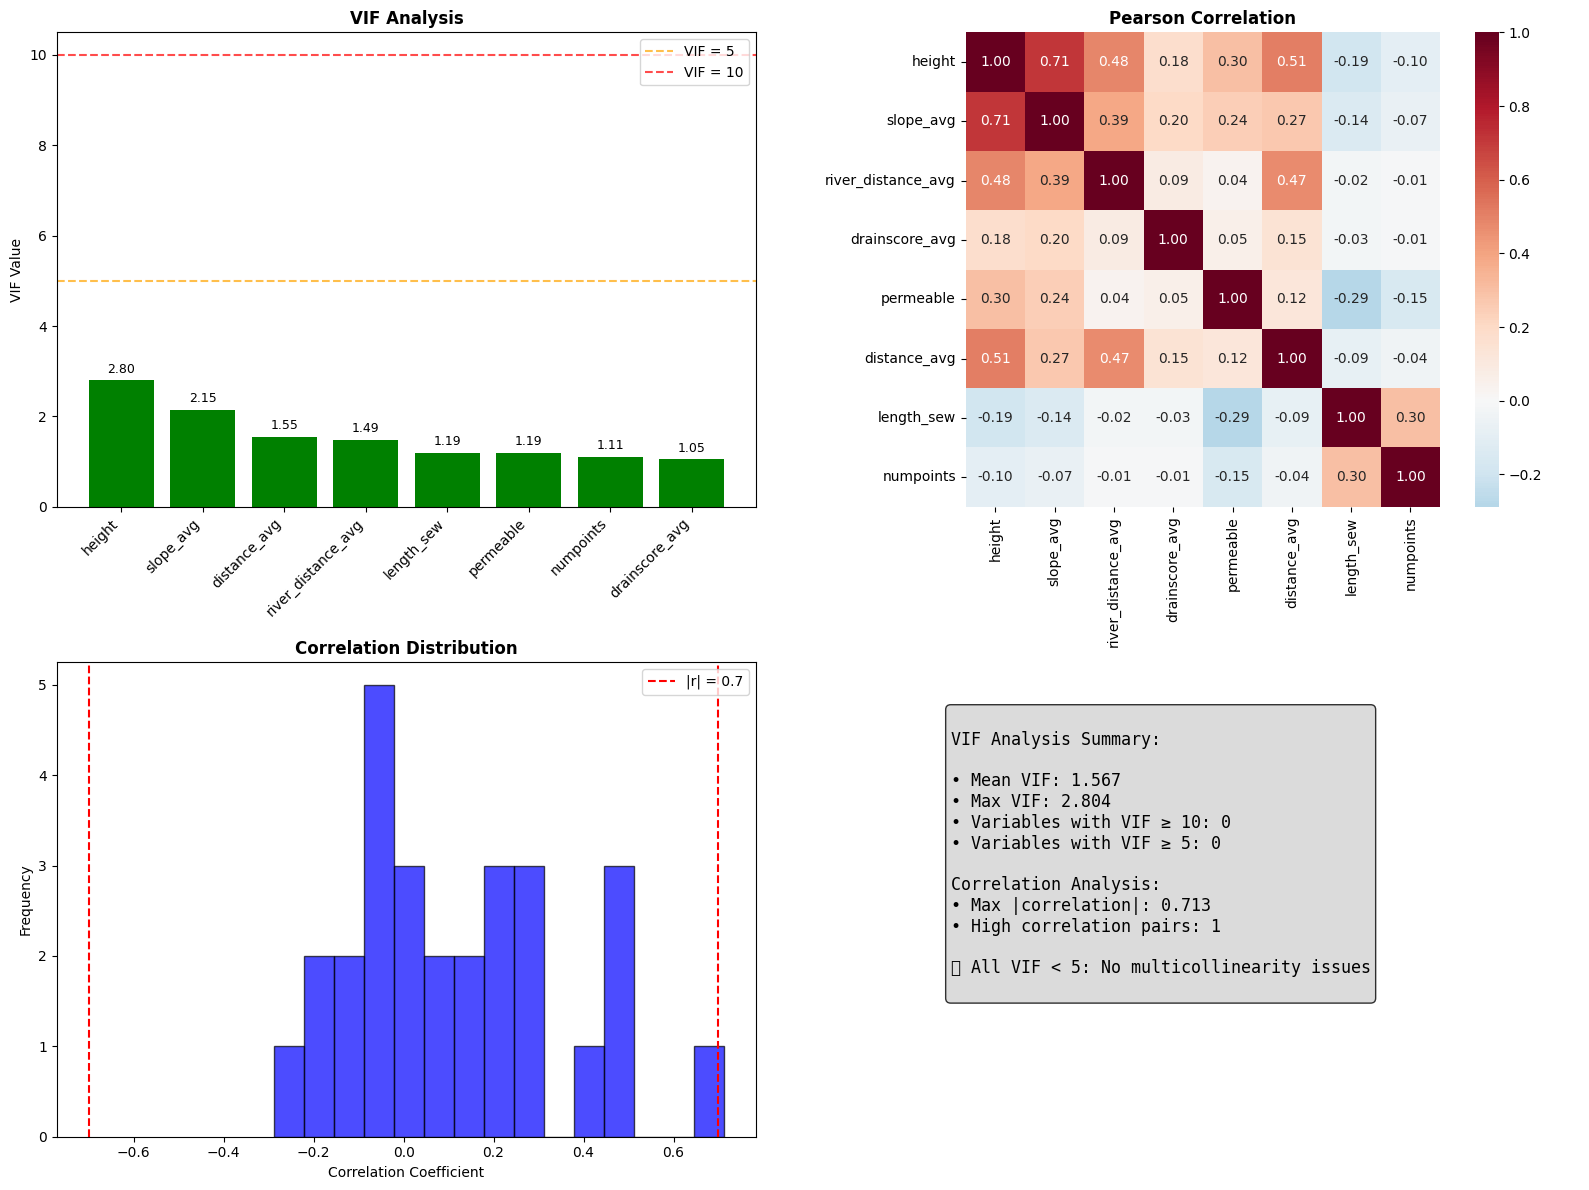

📁 결과 저장: /content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/review_analysis/multicollinearity

2️⃣ 모델 분석...
🤖 저장된 모델 분석 시작...
📂 테스트 데이터 로드...
✅ 테스트 데이터: (759774, 8)
✅ DecisionTree 모델 로드 완료
✅ RandomForest 모델 로드 완료
✅ XGBoost 모델 로드 완료
✅ CatBoost 모델 로드 완료

📈 모델 성능 평가:

🎯 DecisionTree:
  • AUC: 0.9264
  • Accuracy: 0.8049
  • Precision: 0.2549
  • Recall: 0.9191
  • F1-Score: 0.3991

🎯 RandomForest:
  • AUC: 0.9927
  • Accuracy: 0.9647
  • Precision: 0.6783
  • Recall: 0.9488
  • F1-Score: 0.7911

🎯 XGBoost:
  • AUC: 0.9609
  • Accuracy: 0.7519
  • Precision: 0.2211
  • Recall: 0.9984
  • F1-Score: 0.3620

🎯 CatBoost:
  • AUC: 0.9316
  • Accuracy: 0.6825
  • Precision: 0.1816
  • Recall: 0.9995
  • F1-Score: 0.3074

🔧 하이퍼파라미터 분석:

⚙️ DecisionTree 주요 파라미터:
  • max_depth: 20
  • min_samples_leaf: 2
  • min_samples_split: 10

⚙️ RandomForest 주요 파라미터:
  • max_depth: 30
  • min_samples_split: 5
  • n_estimators: 600

⚙️ XGBoost 주요 파라미터:
  • learning_rate: 0.1
  • max_depth:

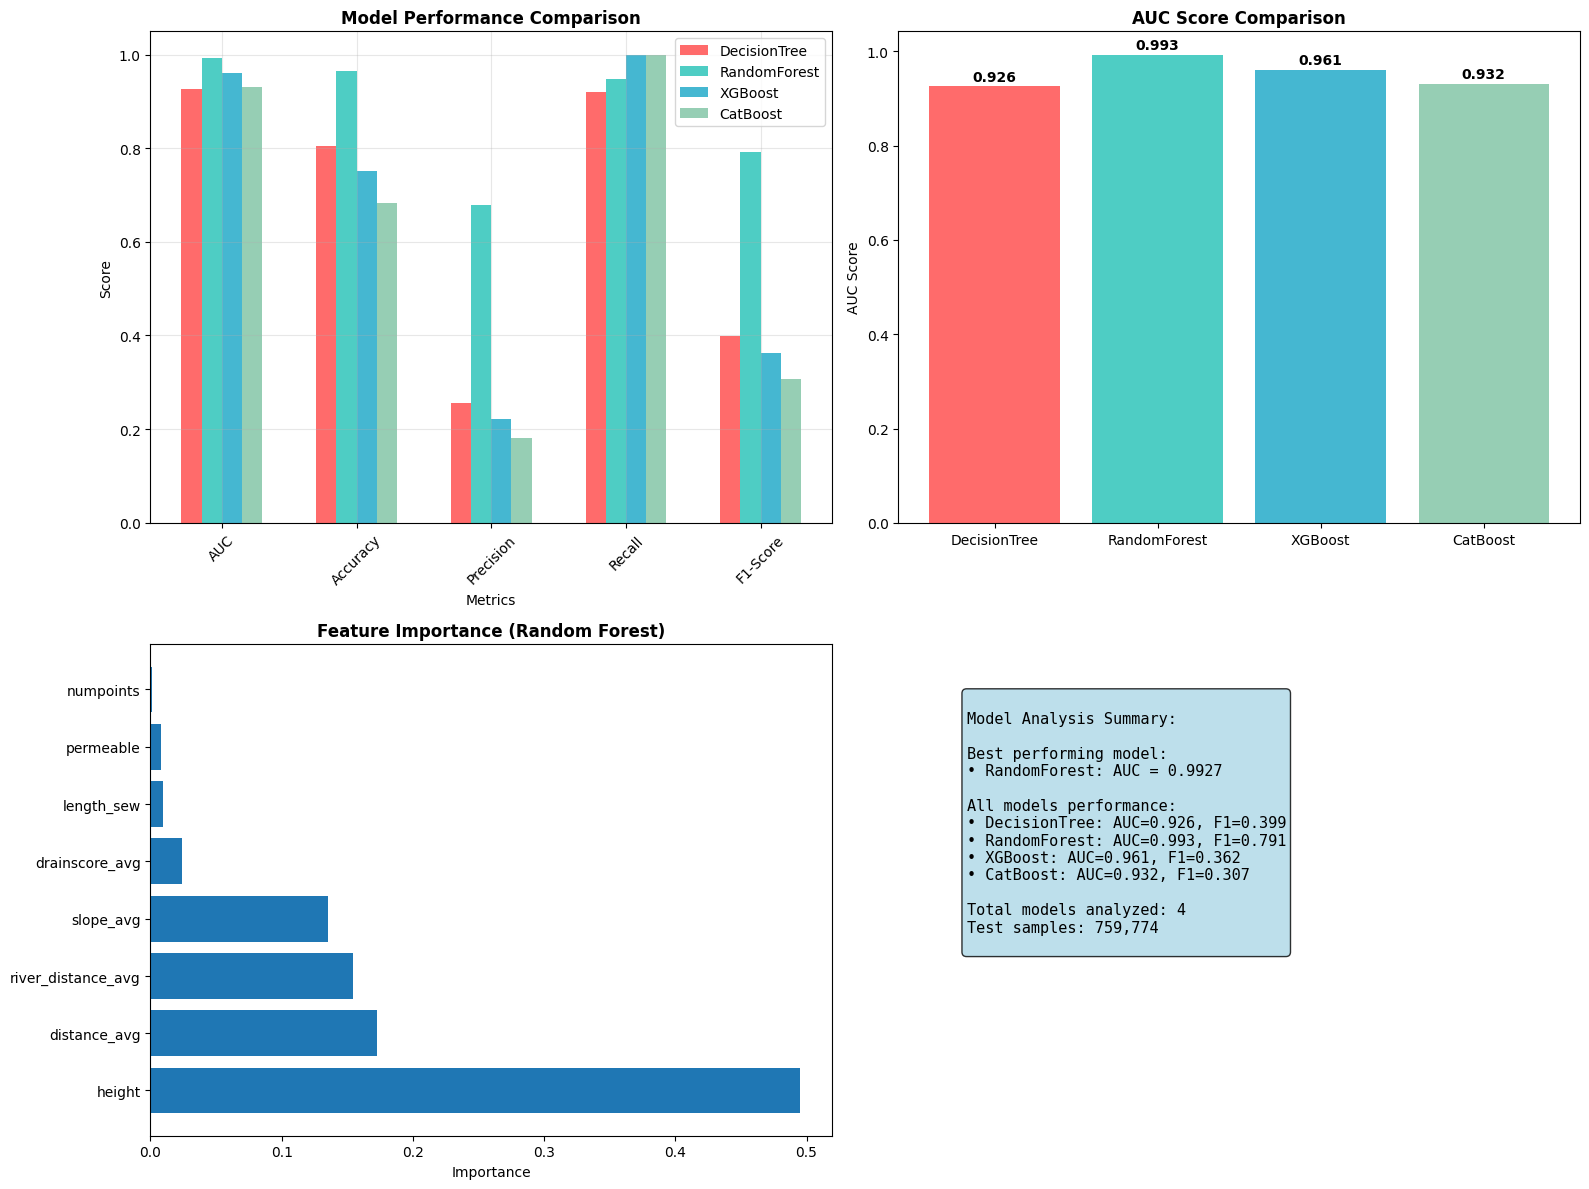

📁 결과 저장: /content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/review_analysis/model_analysis

3️⃣ 논문 요약 생성...
📝 최종 요약 저장: final_summary.md

✅ 모든 분석 완료!
📁 결과 위치: /content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/review_analysis


In [ ]:
 # ==================== 실행 ====================  # 다음 한 줄10,000 실행하면 모든 analysis completed됩니다: multicollinearity_results, model_results = run_review_analysis()

In [ ]:
# -*- coding: utf-8 -*- """ Spearman 상관관계 analysis add existing analysis서 누락 Spearman 매트릭스 generation """  import pandas as pd import numpy as np import matplotlib.pyplot as plt import seaborn as sns from scipy.stats import spearmanr  def spearman_correlation_analysis():  """  Spearman 상관관계 상세 analysis  """   print("🔍 Spearman 상관관계 상세 analysis")  print("=" * 60)   # 1. Load data  csv_path = '/content/drive/MyDrive/URBAN+AI For Paper/파 선 code/SCI/10grid/SCI_flood_risk_data.csv'  features = [  'height','slope_avg','river_distance_avg','drainscore_avg',  'permeable','distance_avg','length_sew','numpoints'  ]   print(f"📂 Load data: {csv_path}")  df = pd.read_csv(csv_path)  X = df[features]  print(f"✅ Load data completed: {X.shape}")   # 2. Spearman 상관관계 calculation  print("\n📈 Spearman 상관관계 매트릭스 calculation...")  corr_spearman = X.corr(method='spearman')   print("\n📊 Spearman 상관관계 매트릭스:")  print(corr_spearman.round(3))   # 3. Pearson vs Spearman comparison  corr_pearson = X.corr(method='pearson')   print("\n🔄 Pearson vs Spearman 차 analysis:")  difference_matrix = np.abs(corr_spearman - corr_pearson)   print("차 매트릭스 (|Spearman - Pearson|):")  print(difference_matrix.round(3))   # 4. 높은 Spearman 상관관계 식by  print("\n⚠️ Spearman 높은 상관관계 (|r| >= 0.7):")  high_corr_spearman = []  for i in range(len(features)):  for j in range(i+1, len(features)):  corr_val = corr_spearman.iloc[i, j]  if abs(corr_val) >= 0.7:  high_corr_spearman.append({  'Variable_1': features[i],  'Variable_2': features[j],  'Spearman_Correlation': corr_val,  'Pearson_Correlation': corr_pearson.iloc[i, j],  'Difference': abs(corr_val - corr_pearson.iloc[i, j])  })   if high_corr_spearman:  high_corr_df = pd.DataFrame(high_corr_spearman)  print("Spearman 높은 상관관계 쌍:")  print(high_corr_df.round(3))  else:  print("✅ Spearman 높은 상관관계 없음 (모두 |r| < 0.7)")   # 5. statistics적 차 analysis  print(f"\n📊 Pearson vs Spearman statistics:")  print(f"평균 절대 차: {difference_matrix.values[np.triu_indices_from(difference_matrix.values, k=1)].mean():.4f}")  print(f"최대 절대 차: {difference_matrix.values[np.triu_indices_from(difference_matrix.values, k=1)].max():.4f}")   # 6. Visualization  print("\n📊 Visualization generation...")  fig, axes = plt.subplots(2, 2, figsize=(16, 12))   # Spearman heatmap  sns.heatmap(corr_spearman, annot=True, cmap='RdBu_r', center=0,  square=True, ax=axes[0,0], fmt='.2f', cbar_kws={'label': 'Spearman Correlation'})  axes[0,0].set_title('Spearman Correlation Matrix', fontsize=14, fontweight='bold')   # Pearson heatmap (comparison용)  sns.heatmap(corr_pearson, annot=True, cmap='RdBu_r', center=0,  square=True, ax=axes[0,1], fmt='.2f', cbar_kws={'label': 'Pearson Correlation'})  axes[0,1].set_title('Pearson Correlation Matrix (comparison)', fontsize=14, fontweight='bold')   # 차 heatmap  sns.heatmap(difference_matrix, annot=True, cmap='Reds',  square=True, ax=axes[1,0], fmt='.3f', cbar_kws={'label': '|Spearman - Pearson|'})  axes[1,0].set_title('Difference Matrix |Spearman - Pearson|', fontsize=14, fontweight='bold')   # scatter plot: Spearman vs Pearson  spearman_vals = corr_spearman.values[np.triu_indices_from(corr_spearman.values, k=1)]  pearson_vals = corr_pearson.values[np.triu_indices_from(corr_pearson.values, k=1)]   axes[1,1].scatter(pearson_vals, spearman_vals, alpha=0.7, s=50)  axes[1,1].plot([-1, 1], [-1, 1], 'r--', alpha=0.8, label='Perfect Agreement')  axes[1,1].set_xlabel('Pearson Correlation')  axes[1,1].set_ylabel('Spearman Correlation')  axes[1,1].set_title('Pearson vs Spearman Correlation', fontsize=14, fontweight='bold')  axes[1,1].legend()  axes[1,1].grid(True, alpha=0.3)   # 대each선 baseline점s  axes[1,1].axhline(y=0.7, color='orange', linestyle='--', alpha=0.7, label='|r| = 0.7')  axes[1,1].axhline(y=-0.7, color='orange', linestyle='--', alpha=0.7)  axes[1,1].axvline(x=0.7, color='orange', linestyle='--', alpha=0.7)  axes[1,1].axvline(x=-0.7, color='orange', linestyle='--', alpha=0.7)   plt.tight_layout()   # Save  output_dir = '/content/drive/MyDrive/URBAN+AI For Paper/딥러닝code/SCI/output/binary/10grid/review_analysis/multicollinearity'  import os  os.makedirs(output_dir, exist_ok=True)   save_path = f'{output_dir}/spearman_analysis_complete.png'  plt.savefig(save_path, dpi=300, bbox_inches='tight')  print(f"📊 Visualization Save: {save_path}")  plt.show()   # 7. result Save  corr_spearman.to_csv(f'{output_dir}/spearman_correlation_matrix.csv')  difference_matrix.to_csv(f'{output_dir}/pearson_spearman_difference.csv')   if high_corr_spearman:  pd.DataFrame(high_corr_spearman).to_csv(f'{output_dir}/high_spearman_correlations.csv', index=False)   print(f"📁 Spearman analysis result Save: {output_dir}")   # 8. 논문용 summary generation  generate_spearman_summary(corr_spearman, corr_pearson, high_corr_spearman, difference_matrix, output_dir)   return {  'spearman_correlation': corr_spearman,  'pearson_correlation': corr_pearson,  'difference_matrix': difference_matrix,  'high_correlations': high_corr_spearman  }  def generate_spearman_summary(corr_spearman, corr_pearson, high_corr_spearman, difference_matrix, output_dir):  """  논문용 Spearman analysis summary generation  """   # statistics calculation  max_spearman = np.abs(corr_spearman.values[np.triu_indices_from(corr_spearman.values, k=1)]).max()  max_pearson = np.abs(corr_pearson.values[np.triu_indices_from(corr_pearson.values, k=1)]).max()  mean_diff = difference_matrix.values[np.triu_indices_from(difference_matrix.values, k=1)].mean()  max_diff = difference_matrix.values[np.triu_indices_from(difference_matrix.values, k=1)].max()   summary_text = f""" # Spearman 상관관계 analysis summary  ## 주요 result:  ### Spearman vs Pearson comparison: - 최대 Spearman 상관계count: {max_spearman:.3f} - 최대 Pearson 상관계count: {max_pearson:.3f} - 평균 절대 차: {mean_diff:.4f} - 최대 절대 차: {max_diff:.4f}  ### 높은 Spearman 상관관계: """   if high_corr_spearman:  summary_text += f"- {len(high_corr_spearman)}items 변count 쌍 |r| ≥ 0.7\n"  for pair in high_corr_spearman:  summary_text += f" • {pair['Variable_1']} vs {pair['Variable_2']}: r = {pair['Spearman_Correlation']:.3f}\n"  else:  summary_text += "- 높은 Spearman 상관관계 없음 (모두 |r| < 0.7)\n"   summary_text += f"""  ### 결론: ✅ Spearman과 Pearson 상관관계가 매우 유사함 (평균 차 {mean_diff:.4f}) ✅ 비선형 관계나 상치 영향 minimum한임을 verify ✅ 변counts 간 관계가 대부분 선형적 feature을 가짐  ## 논문 add 내용:  **Methodology 섹션 add:** "Both Pearson and Spearman correlation analyses were conducted to assess linear and monotonic relationships between variables. The results showed high concordance between Pearson and Spearman correlations (mean absolute difference = {mean_diff:.4f}), indicating that relationships between variables are predominantly linear with minimal influence from outliers or non-linear associations."  **Results 섹션 add:** "Spearman rank correlation analysis confirmed the Pearson correlation findings, with a maximum correlation of {max_spearman:.3f} and identical identification of high-correlation variable pairs. The strong concordance between Pearson and Spearman results (mean difference = {mean_diff:.4f}) validates the appropriateness of linear modeling approaches for this dataset." """   # file Save  with open(f'{output_dir}/spearman_analysis_summary.md', 'w', encoding='utf-8') as f:  f.write(summary_text)   print("📝 Spearman analysis summary Save: spearman_analysis_summary.md")  

🔍 Spearman 상관관계 상세 분석
📂 데이터 로드: /content/drive/MyDrive/URBAN+AI For Paper/파이선 코드/SCI/10grid/SCI_flood_risk_data.csv
✅ 데이터 로드 완료: (2532578, 8)

📈 Spearman 상관관계 매트릭스 계산...

📊 Spearman 상관관계 매트릭스:
                    height  slope_avg  river_distance_avg  drainscore_avg  \
height               1.000      0.751               0.261           0.258   
slope_avg            0.751      1.000               0.241           0.262   
river_distance_avg   0.261      0.241               1.000           0.136   
drainscore_avg       0.258      0.262               0.136           1.000   
permeable            0.372      0.338              -0.009           0.067   
distance_avg         0.468      0.365               0.291           0.241   
length_sew          -0.259     -0.222               0.007          -0.039   
numpoints           -0.131     -0.110               0.006          -0.017   

                    permeable  distance_avg  length_sew  numpoints  
height                  0.372         0.468 

/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipython-input-13-3284964427.py:121: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-13-3284964427.py:121: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-13-3284964427.py:121: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-13-3284964427.py:121: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  

📊 시각화 저장: /content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/review_analysis/multicollinearity/spearman_analysis_complete.png


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


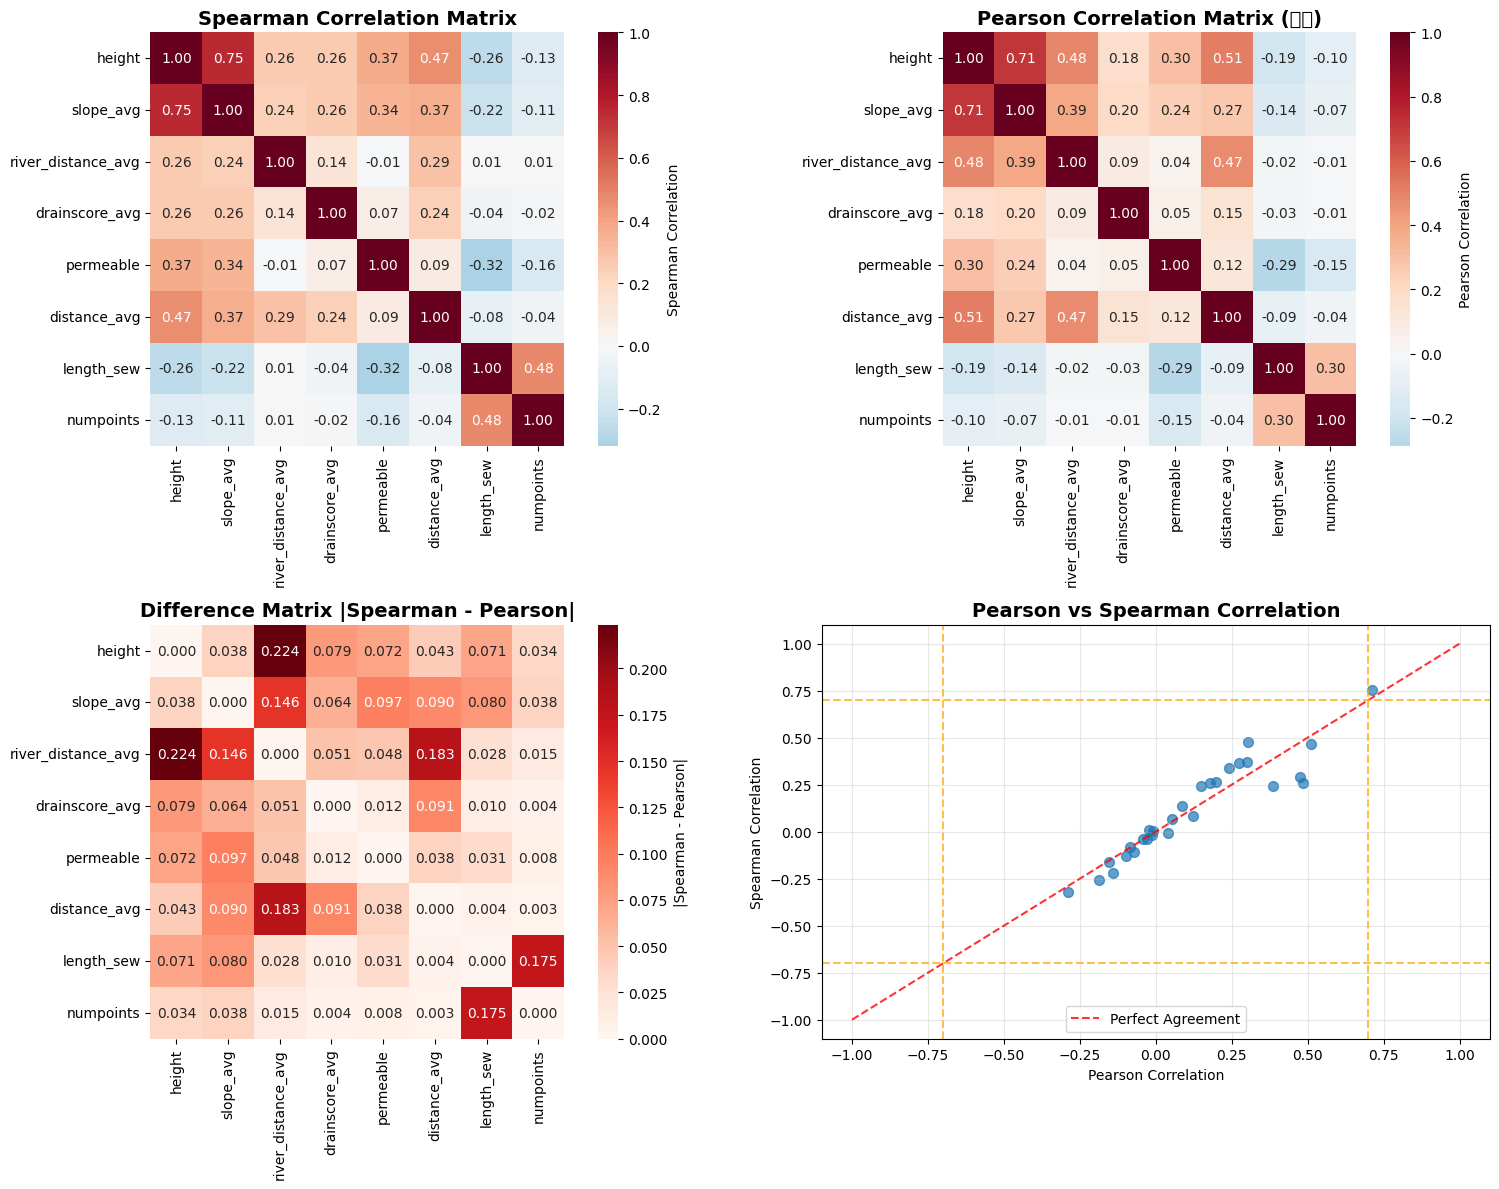

📁 Spearman 분석 결과 저장: /content/drive/MyDrive/URBAN+AI For Paper/딥러닝코드/SCI/output/binary/10grid/review_analysis/multicollinearity
📝 Spearman 분석 요약 저장: spearman_analysis_summary.md


In [ ]:
# ==================== 실행 ====================  # 다음 code 실행하면 Spearman analysis completed됩니다: spearman_results = spearman_correlation_analysis()